In [27]:
!pip install geopandas

<h1 style="font-size:40px;">Importación de base: Empleo y remuneraciones por departamento</h1>


In [28]:
# %% ------------------------------------
# 📦 Configuración inicial
# %% ------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style="whitegrid")

# Ruta base
RUTA_BASE = r"C:\Users\Machi Pardini\Documents\GitHub\Big-Data-UBA--Grupo-3\BASES"

# %% ------------------------------------
# 📂 Carga de bases de datos
# %% ------------------------------------
ARCHIVO_EMPLEO = os.path.join(RUTA_BASE, "mteyss_oede_estimacion-por-departamento_y_sector_series_empleo_y_salarios_mensual.csv")

# Cargar bases
try:
    empleo = pd.read_csv(ARCHIVO_EMPLEO, encoding="utf-8")
    print(f"✅ Base Empleo cargada. Filas: {empleo.shape[0]} | Columnas: {empleo.shape[1]}")
except Exception as e:
    print("⚠️ Error al cargar Empleo:", e)

# %% ------------------------------------
# 🔍 Exploración inicial
# %% ------------------------------------
print("\nColumnas Empleo:\n", empleo.columns.tolist())

def diccionario_variables(df):
    """Resumen de variables, tipos de datos y porcentaje de nulos."""
    return pd.DataFrame({
        "variable": df.columns,
        "tipo_dato": df.dtypes.astype(str),
        "nulos_%": (df.isnull().mean() * 100).round(2)
    })

# Crear diccionarios
dicc_empleo = diccionario_variables(empleo)

# Guardar para revisión rápida
dicc_empleo.to_csv(os.path.join(RUTA_BASE, "diccionario_empleo.csv"), index=False, encoding="utf-8")
print("\n📁 Diccionario guardado en carpeta BASES")

✅ Base Empleo cargada. Filas: 293496 | Columnas: 8

Columnas Empleo:
 ['provi_id', 'desc_provincia', 'depto_final', 'desc_departamento', 'sector', 'periodo', 'empleo', 'salarios']

📁 Diccionario guardado en carpeta BASES


<h1 style="font-size:40px;">Limpieza</h1>

In [29]:
# =====================================================
# Verificación de nombres de provincias y departamentos
# =====================================================

# Este bloque sirve para revisar cómo están escritos los nombres
# de provincias y departamentos en la base 'empleo', detectar posibles
# inconsistencias o duplicados, y preparar la creación de una variable
# combinada (provincia + departamento).

# Provincias únicas
# Se listan los nombres de provincias presentes en la base, ordenados alfabéticamente.
print("Provincias únicas:")
print(empleo['desc_provincia'].sort_values().unique())

# Departamentos únicos
# Se listan los nombres de departamentos, también ordenados.
print("\nDepartamentos únicos:")
print(empleo['desc_departamento'].sort_values().unique())

# Combinación provincia + departamento
# Se muestra la combinación única de provincia y departamento.
# Esto permite verificar si hay repeticiones o errores en la forma
# en que se nombran las localidades dentro de cada provincia.
print("\nProvincias + departamentos únicos:")
print(
    empleo[['desc_provincia', 'desc_departamento']]
    .drop_duplicates()                                   # elimina filas repetidas
    .sort_values(['desc_provincia', 'desc_departamento']) # ordena alfabéticamente
)


Provincias únicas:
['BUENOS AIRES' 'CATAMARCA' 'CHACO' 'CHUBUT'
 'CIUDAD AUTONOMA DE BUENOS AIRES' 'CORDOBA' 'CORRIENTES' 'ENTRE RIOS'
 'FORMOSA' 'JUJUY' 'LA PAMPA' 'LA RIOJA' 'MENDOZA' 'MISIONES' 'NEUQUEN'
 'RIO NEGRO' 'SALTA' 'SAN JUAN' 'SAN LUIS' 'SANTA CRUZ' 'SANTA FE'
 'SANTIAGO DEL ESTERO' 'TIERRA DEL FUEGO' 'TUCUMAN']

Departamentos únicos:
['12 de Octubre' '2 de Abril' '25 de Mayo' '25 de Mayo ' '9 de Julio'
 '9 de Julio ' '9 de julio ' 'Adolfo Alsina' 'Adolfo Alsina '
 'Adolfo Gonzales Chaves' 'Aguirre ' 'Albardón ' 'Alberdi ' 'Alberti'
 'Almirante Brown' 'Aluminé ' 'Ambato' 'Ancasti' 'Andalgalá' 'Angaco '
 'Anta ' 'Antofagasta de la Sierra' 'Apóstoles ' 'Arauco ' 'Arrecifes'
 'Atamisqui ' 'Atreucó ' 'Avellaneda' 'Avellaneda ' 'Ayacucho' 'Ayacucho '
 'Azul' 'Añelo ' 'Bahía Blanca' 'Balcarce' 'Banda ' 'Baradero'
 'Bariloche ' 'Belgrano ' 'Bella Vista' 'Belén' 'Benito Juárez'
 'Berazategui' 'Berisso' 'Bermejo' 'Berón de Astrada' 'Biedma' 'Bolívar'
 'Bragado' 'Brandsen' 'Burruyac

In [30]:
# 1️⃣ Limpieza básica
empleo['desc_provincia'] = empleo['desc_provincia'].str.strip()
empleo['desc_departamento'] = empleo['desc_departamento'].str.strip()

# 2️⃣ Normalización
def normalizar_texto(col):
    reemplazos = {
        "á": "a", "é": "e", "í": "i", "ó": "o", "ú": "u",
        "ñ": "n", "ü": "u"
    }
    col = col.str.lower()
    for k, v in reemplazos.items():
        col = col.str.replace(k, v, regex=False)
    return col

empleo['prov_clean'] = normalizar_texto(empleo['desc_provincia'])
empleo['dep_clean']  = normalizar_texto(empleo['desc_departamento'])

# 4️⃣ Crear DEP_ID
empleo['DEP_ID'] = (
    empleo['prov_clean'].str.strip() + "_" + empleo['dep_clean'].str.strip()
)

# 5️⃣ Limpieza final
empleo['DEP_ID'] = (
    empleo['DEP_ID']
    .str.replace(r"\s+", "_", regex=True)
    .replace({
        'santiago_del_estero_general_taboada ': 'santiago_del_estero_general_taboada',
        'san_luis_general_pedernera ': 'san_luis_general_pedernera'
    })
)
# 6️⃣ Listado completo de departamentos estandarizados únicos
departamentos_unicos = sorted(empleo['DEP_ID'].unique())

print("=== Listado completo de departamentos estandarizados ===")
for dep in departamentos_unicos:
    print(dep)

print("\n=== Total de departamentos únicos ===")
print(len(departamentos_unicos))


=== Listado completo de departamentos estandarizados ===
buenos_aires_25_de_mayo
buenos_aires_9_de_julio
buenos_aires_adolfo_alsina
buenos_aires_adolfo_gonzales_chaves
buenos_aires_alberti
buenos_aires_almirante_brown
buenos_aires_arrecifes
buenos_aires_avellaneda
buenos_aires_ayacucho
buenos_aires_azul
buenos_aires_bahia_blanca
buenos_aires_balcarce
buenos_aires_baradero
buenos_aires_benito_juarez
buenos_aires_berazategui
buenos_aires_berisso
buenos_aires_bolivar
buenos_aires_bragado
buenos_aires_brandsen
buenos_aires_campana
buenos_aires_canuelas
buenos_aires_capitan_sarmiento
buenos_aires_carlos_casares
buenos_aires_carlos_tejedor
buenos_aires_carmen_de_areco
buenos_aires_castelli
buenos_aires_chacabuco
buenos_aires_chascomus
buenos_aires_chivilcoy
buenos_aires_colon
buenos_aires_coronel_de_marina_leonardo_rosales
buenos_aires_coronel_dorrego
buenos_aires_coronel_pringles
buenos_aires_coronel_suarez
buenos_aires_daireaux
buenos_aires_dolores
buenos_aires_ensenada
buenos_aires_escoba

In [31]:
"DEP_ID" in empleo.columns


True

In [32]:
print(empleo.columns.tolist())


['provi_id', 'desc_provincia', 'depto_final', 'desc_departamento', 'sector', 'periodo', 'empleo', 'salarios', 'prov_clean', 'dep_clean', 'DEP_ID']


In [33]:
# =====================================================
# Asignación y verificación de departamentos tratados
# =====================================================

# 1️⃣ Inicializar la variable 'dep_tratado' en 0 para todos los registros
empleo['dep_tratado'] = 0

# 2️⃣ Definir la lista completa de departamentos tratados
tratados = [
    'buenos_aires_bahia_blanca', 'buenos_aires_ensenada', 'buenos_aires_general_villegas',
    'buenos_aires_la_matanza', 'buenos_aires_ramallo', 'buenos_aires_villarino',
    'catamarca_capayan', 'catamarca_la_paz', 'catamarca_tinogasta',
    'chaco_general_donovan', 'chaco_libertad',
    'chubut_biedma', 'chubut_escalante', 'chubut_florentino_ameghino', 'chubut_rawson',
    'corrientes_concepcion', 'corrientes_santo_tome',
    'formosa_formosa', 'formosa_patino',
    'mendoza_general_alvear', 'mendoza_junin', 'mendoza_lavalle', 'mendoza_la_paz',
    'mendoza_lujan_de_cuyo', 'mendoza_maipu', 'mendoza_san_martin', 'mendoza_san_rafael', 'mendoza_tupungato',
    'misiones_leandro_n._alem', 'misiones_libertador_general_san_martin',
    'neuquen_picunches',
    'rio_negro_avellaneda', 'rio_negro_bariloche', 'rio_negro_pilcaniyeu',
    'salta_cafayate', 'salta_los_andes',
    'san_luis_general_pedernera',
    'san_juan_iglesia', 'san_juan_sarmiento', 'san_juan_ullum',
    'santa_cruz_deseado',
    'santa_fe_castellanos', 'santa_fe_constitucion', 'santa_fe_general_lopez',
    'santa_fe_general_obligado', 'santa_fe_la_capital', 'santa_fe_san_lorenzo',
    'santiago_del_estero_general_taboada',
    'tucuman_burruyacu', 'tucuman_cruz_alta', 'tucuman_leales',
    'jujuy_susques',
    'buenos_aires_capitan_sarmiento', 'buenos_aires_general_alvarado',
    'buenos_aires_general_alvear', 'buenos_aires_necochea', 'buenos_aires_pergamino',
    'buenos_aires_rojas', 'buenos_aires_roque_perez', 'buenos_aires_saladillo',
    'buenos_aires_tornquist', 'buenos_aires_tres_arroyos',
    'cordoba_colon', 'cordoba_cruz_del_eje', 'cordoba_general_roca',
    'cordoba_general_san_martin', 'cordoba_juarez_celman', 'cordoba_marcos_juarez',
    'cordoba_rio_cuarto', 'cordoba_rio_segundo', 'cordoba_rio_seco',
    'cordoba_san_alberto', 'cordoba_san_javier', 'cordoba_san_justo',
    'la_pampa_puelen', 'la_pampa_utracan',
    'la_rioja_arauco', 'la_rioja_chilecito'
]

# 3️⃣ Asignar 1 a los departamentos cuyo DEP_ID_std esté en la lista de tratados
empleo['dep_tratado'] = empleo['DEP_ID'].isin(tratados).astype(int)

# 4️⃣ Listar los departamentos tratados únicos y ordenados alfabéticamente
departamentos_tratados_unicos = sorted(empleo.loc[empleo['dep_tratado'] == 1, 'DEP_ID'].unique())

print("=== Listado completo de departamentos tratados (dep_tratado = 1) ===")
for dep in departamentos_tratados_unicos:
    print(dep)

print(f"\n=== Total de departamentos tratados: {len(departamentos_tratados_unicos)} ===")


=== Listado completo de departamentos tratados (dep_tratado = 1) ===
buenos_aires_bahia_blanca
buenos_aires_capitan_sarmiento
buenos_aires_ensenada
buenos_aires_general_alvarado
buenos_aires_general_alvear
buenos_aires_general_villegas
buenos_aires_la_matanza
buenos_aires_necochea
buenos_aires_pergamino
buenos_aires_ramallo
buenos_aires_rojas
buenos_aires_roque_perez
buenos_aires_saladillo
buenos_aires_tornquist
buenos_aires_tres_arroyos
buenos_aires_villarino
catamarca_capayan
catamarca_la_paz
catamarca_tinogasta
chaco_libertad
chubut_biedma
chubut_escalante
chubut_florentino_ameghino
chubut_rawson
cordoba_colon
cordoba_cruz_del_eje
cordoba_general_roca
cordoba_general_san_martin
cordoba_juarez_celman
cordoba_marcos_juarez
cordoba_rio_cuarto
cordoba_rio_seco
cordoba_rio_segundo
cordoba_san_alberto
cordoba_san_javier
cordoba_san_justo
corrientes_concepcion
corrientes_santo_tome
formosa_formosa
formosa_patino
jujuy_susques
la_pampa_puelen
la_pampa_utracan
la_rioja_arauco
la_rioja_chilec


=== Registros con valores fuera de rango lógico ===
Empty DataFrame
Columns: [provi_id, provincia, depto_final, departamento, DEP_ID, dep_tratado, sector, periodo, empleo, salarios]
Index: []

=== Porcentaje de valores faltantes por variable ===
salarios        30.783384
empleo          30.783384
provincia        0.000000
provi_id         0.000000
depto_final      0.000000
departamento     0.000000
dep_tratado      0.000000
DEP_ID           0.000000
periodo          0.000000
sector           0.000000
dtype: float64


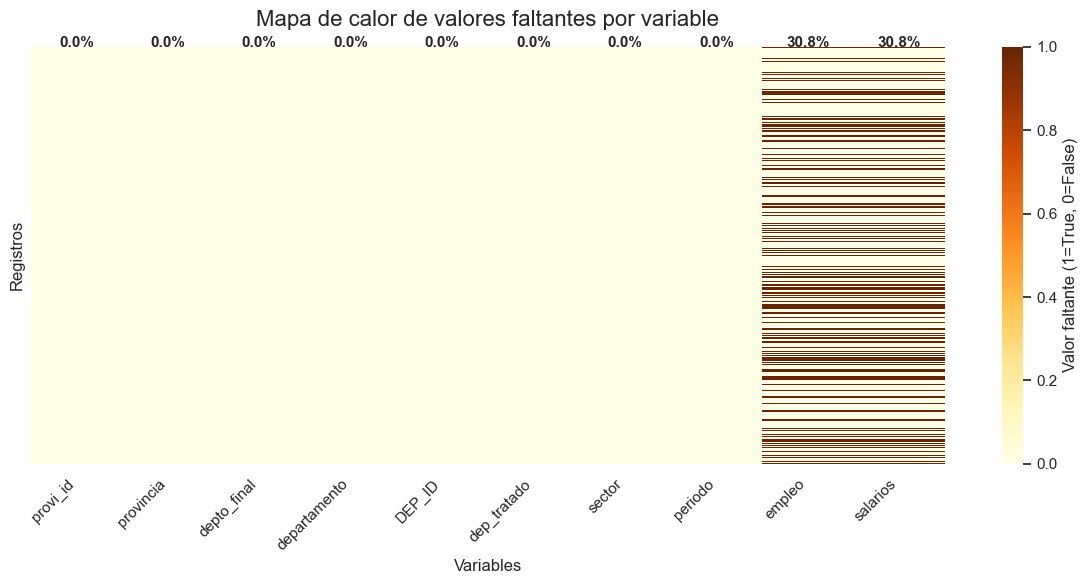


✅ Limpieza completada: tipos corregidos, valores faltantes analizados y valores fuera de rango reemplazados por NaN.


In [34]:
# ==============================================================
# Limpieza y validación de variables
# ==============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1️⃣ Renombrar columnas
# -------------------------------
empleo = empleo.rename(columns={
    'desc_provincia': 'provincia',
    'desc_departamento': 'departamento'
})

# -------------------------------
# 2️⃣ Definir variables de interés
# -------------------------------
vars_interes = [
    'provi_id', 'provincia', 'depto_final', 'departamento','DEP_ID',
    'dep_tratado', 'sector', 'periodo', 'empleo', 'salarios'
]

df = empleo[vars_interes].copy()

# -------------------------------
# 3️⃣ Convertir tipos de datos
# -------------------------------
df['periodo'] = pd.to_numeric(df['periodo'], errors='coerce').astype('Int64')
df['dep_tratado'] = df['dep_tratado'].astype('Int64')
df['sector'] = df['sector'].astype('category')
df['provincia'] = df['provincia'].astype('category')
df['departamento'] = df['departamento'].astype('category')
df['empleo'] = pd.to_numeric(df['empleo'], errors='coerce')
df['salarios'] = pd.to_numeric(df['salarios'], errors='coerce')

# -------------------------------
# 4️⃣ Detección de valores fuera de rango
# -------------------------------
valores_invalidos = df[(df['empleo'] <= 0) | (df['salarios'] <= 0)]
print("\n=== Registros con valores fuera de rango lógico ===")
print(valores_invalidos.head())

# Reemplazar por NaN
df.loc[df['empleo'] <= 0, 'empleo'] = np.nan
df.loc[df['salarios'] <= 0, 'salarios'] = np.nan

# Actualizar dataset principal
empleo = empleo.assign(
    empleo=df['empleo'],
    salarios=df['salarios']
)

# -------------------------------
# 5️⃣ Porcentaje de valores faltantes por columna
# -------------------------------
faltantes_pct = df.isna().mean() * 100
print("\n=== Porcentaje de valores faltantes por variable ===")
print(faltantes_pct.sort_values(ascending=False))


# -------------------------------
# 6️⃣ Heatmap mejorado de valores faltantes (paleta sepia)
# -------------------------------
plt.figure(figsize=(12, 6))
sns.heatmap(
    df.isna(),
    cmap='YlOrBr',                 # paleta sepia: amarillo → naranja → marrón
    cbar=True,
    cbar_kws={'label': 'Valor faltante (1=True, 0=False)'},
    yticklabels=False
)

# Añadir título y etiquetas
plt.title("Mapa de calor de valores faltantes por variable", fontsize=16, pad=15)
plt.xlabel("Variables", fontsize=12)
plt.ylabel("Registros", fontsize=12)

# Añadir anotaciones de porcentaje de valores faltantes encima de cada columna
for idx, col in enumerate(df.columns):
    plt.text(
        idx + 0.5,                    # posición x (centrado en la columna)
        -5,                           # posición y (por encima del heatmap)
        f"{faltantes_pct[col]:.1f}%", # texto: porcentaje
        ha='center', fontsize=11, fontweight='bold'
    )

plt.xticks(rotation=45, ha='right')  # rotar nombres de variables
plt.tight_layout()
plt.savefig("heatmap_valores_faltantes_anotado_sepia.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Limpieza completada: tipos corregidos, valores faltantes analizados y valores fuera de rango reemplazados por NaN.")


In [35]:
print(empleo.columns)


Index(['provi_id', 'provincia', 'depto_final', 'departamento', 'sector',
       'periodo', 'empleo', 'salarios', 'prov_clean', 'dep_clean', 'DEP_ID',
       'dep_tratado'],
      dtype='object')


In [36]:
# =====================================================
# Tabla de departamentos única (corregido)
# =====================================================
dept_dic = empleo[['DEP_ID', 'provincia', 'departamento']].drop_duplicates().copy()

# =====================================================
# Función para extraer provincia desde DEP_ID
# =====================================================
def extraer_provincia_completa(dep_id):
    dep_id = dep_id.lower()
    
    if dep_id.startswith("ciudad_autonoma"):
        return "ciudad_autonoma_de_buenos_aires"

    mappings = [
        "buenos_aires", "entre_rios", "la_pampa", "la_rioja", "rio_negro",
        "santa_cruz", "santa_fe", "santiago_del_estero", "tierra_del_fuego",
        "san_juan", "san_luis", "mendoza", "cordoba", "corrientes",
        "formosa", "misiones", "neuquen", "salta", "jujuy", "tucuman",
        "chaco", "chubut", "catamarca"
    ]

    for prov in mappings:
        if dep_id.startswith(prov + "_"):
            return prov

    return dep_id.split("_")[0]

# Aplicar
dept_dic['provincia_completa'] = dept_dic['DEP_ID'].apply(extraer_provincia_completa)

# Control
control_total = dept_dic[['DEP_ID', 'provincia_completa']].sort_values('provincia_completa')
print(control_total)

print("\nCantidad de departamentos por provincia:")
print(control_total['provincia_completa'].value_counts())


                               DEP_ID provincia_completa
78624         buenos_aires_san_isidro       buenos_aires
58380           buenos_aires_mercedes       buenos_aires
59052              buenos_aires_merlo       buenos_aires
59724              buenos_aires_monte       buenos_aires
60312      buenos_aires_monte_hermoso       buenos_aires
...                               ...                ...
285012  tucuman_juan_bautista_alberdi            tucuman
284508               tucuman_graneros            tucuman
282324              tucuman_burruyacu            tucuman
282744              tucuman_cruz_alta            tucuman
284004               tucuman_famailla            tucuman

[520 rows x 2 columns]

Cantidad de departamentos por provincia:
provincia_completa
buenos_aires                       135
santiago_del_estero                 27
cordoba                             26
corrientes                          25
chaco                               23
salta                               

In [45]:
# ==============================================================
# 0️⃣ Agregar columna provincia_completa al DataFrame original
# ==============================================================

# 🔹 Función para mapear cada DEP_ID a su provincia completa
def extraer_provincia_completa(dep_id):
    dep_id = str(dep_id).lower()

    # Casos especiales y provincias compuestas
    patrones = {
        "ciudad_autonoma": "ciudad_autonoma_de_buenos_aires",
        "buenos_aires_": "buenos_aires",
        "entre_rios_": "entre_rios",
        "la_pampa_": "la_pampa",
        "la_rioja_": "la_rioja",
        "rio_negro_": "rio_negro",
        "santa_cruz_": "santa_cruz",
        "santa_fe_": "santa_fe",
        "santiago_del_estero_": "santiago_del_estero",
        "tierra_del_fuego_": "tierra_del_fuego",
        "san_juan_": "san_juan",
        "san_luis_": "san_luis",
        "mendoza_": "mendoza",
        "cordoba_": "cordoba",
        "corrientes_": "corrientes",
        "formosa_": "formosa",
        "misiones_": "misiones",
        "neuquen_": "neuquen",
        "salta_": "salta",
        "jujuy_": "jujuy",
        "tucuman_": "tucuman"
    }

    for prefijo, provincia in patrones.items():
        if dep_id.startswith(prefijo):
            return provincia

    # Fallback: usar la primera palabra
    return dep_id.split("_")[0]


# ==============================================================
# 1️⃣ Aplicar provincia_completa al dataset principal
# ==============================================================

empleo['provincia_completa'] = empleo['DEP_ID'].apply(extraer_provincia_completa)


# ==============================================================
# 2️⃣ Crear tabla única de departamentos
# ==============================================================

dept_dic = empleo[['DEP_ID', 'provincia_completa', 'departamento']].drop_duplicates()


# ==============================================================
# 3️⃣ Cantidad REAL de departamentos por provincia
# ==============================================================

print("\nCantidad REAL de departamentos por provincia:")
print(
    dept_dic.groupby("provincia_completa")
    .size()
    .sort_values(ascending=False)
)

# Control rápido (primeras 20 filas)
print("\nControl rápido (primeras 20 combinaciones únicas):")
print(
    dept_dic.sort_values('provincia_completa').head(20)
)



Cantidad REAL de departamentos por provincia:
provincia_completa
buenos_aires                       135
santiago_del_estero                 27
cordoba                             26
corrientes                          25
chaco                               23
salta                               22
la_pampa                            21
santa_fe                            19
san_juan                            18
la_rioja                            18
mendoza                             18
entre_rios                          17
tucuman                             17
misiones                            16
catamarca                           16
ciudad_autonoma_de_buenos_aires     16
neuquen                             16
chubut                              15
jujuy                               15
rio_negro                           13
san_luis                             9
formosa                              8
santa_cruz                           7
tierra_del_fuego                     

# Primer análisis exploratorio


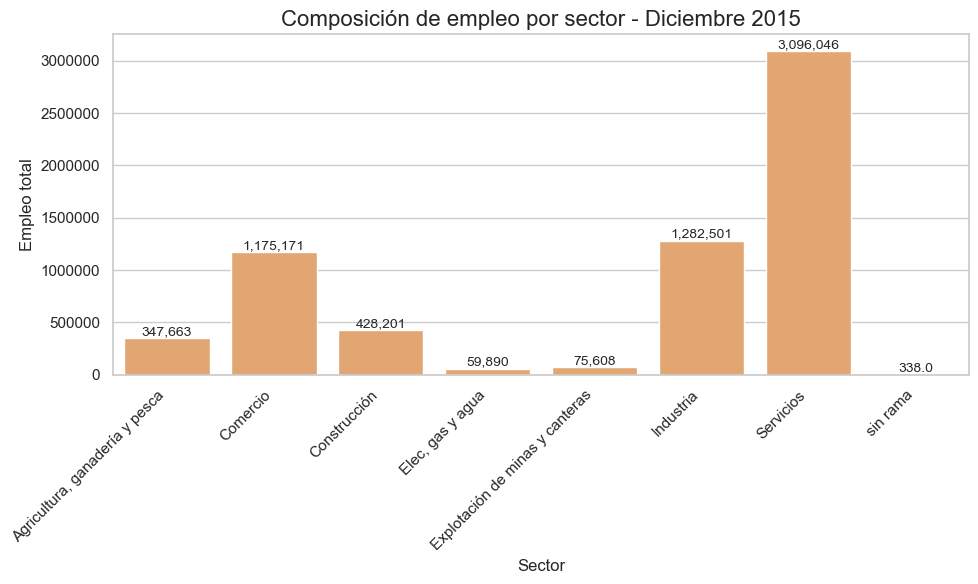

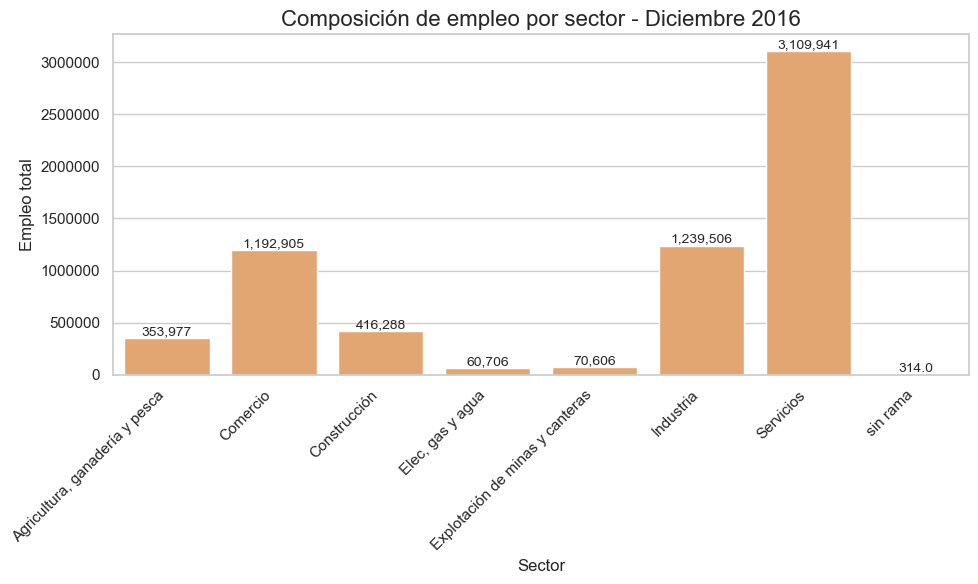

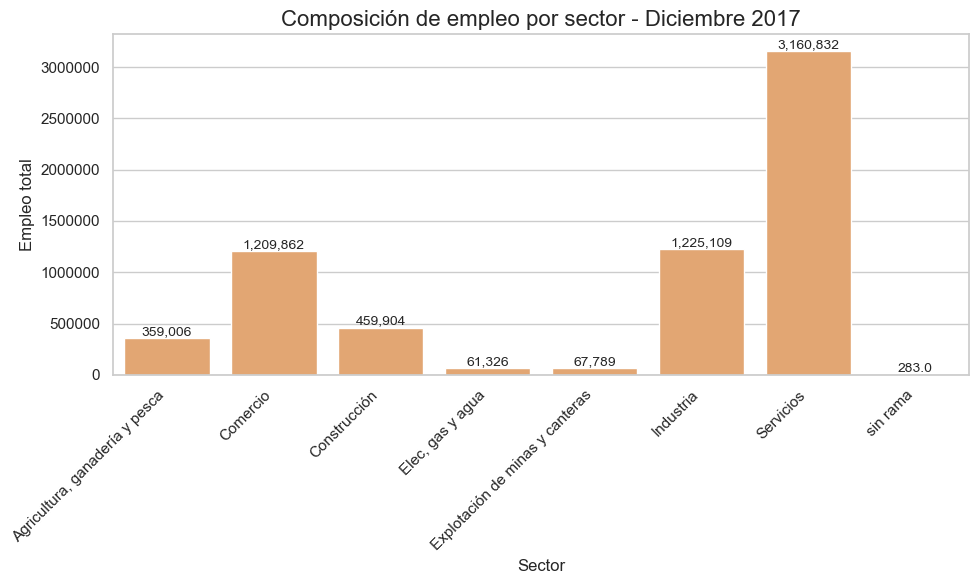

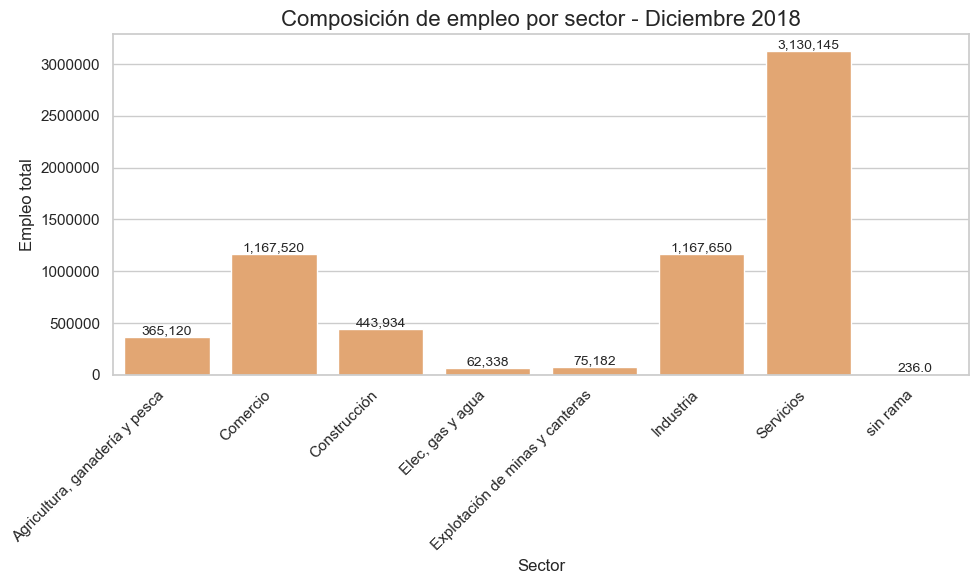

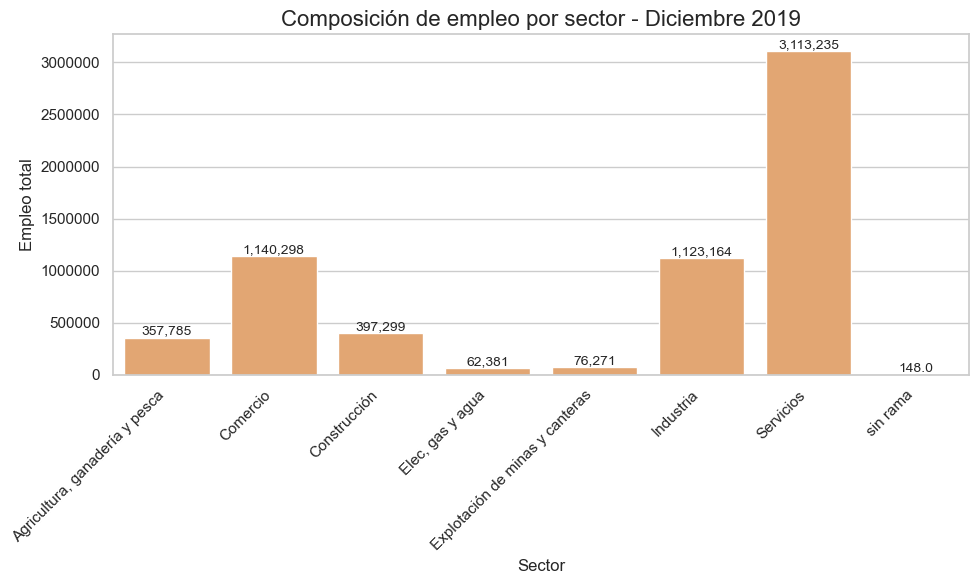

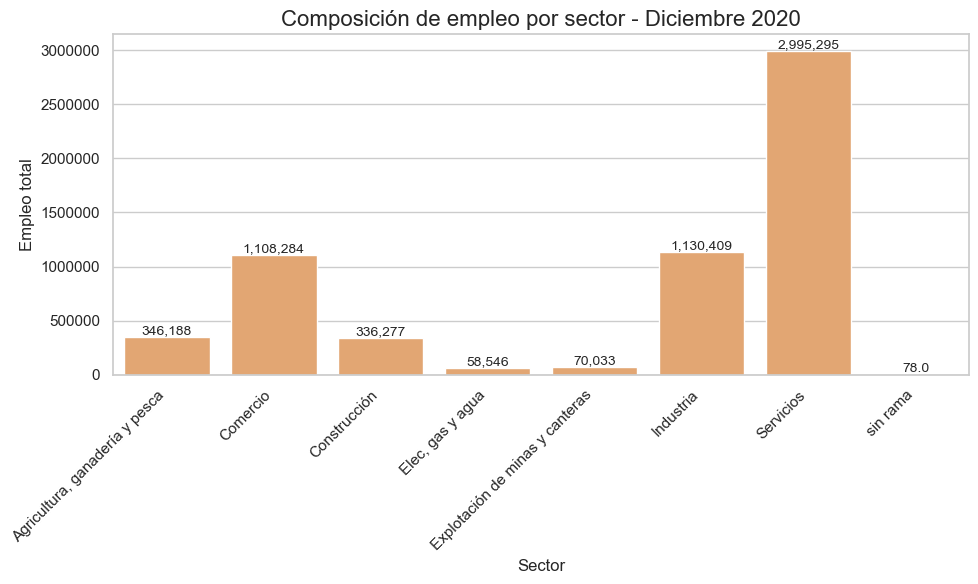

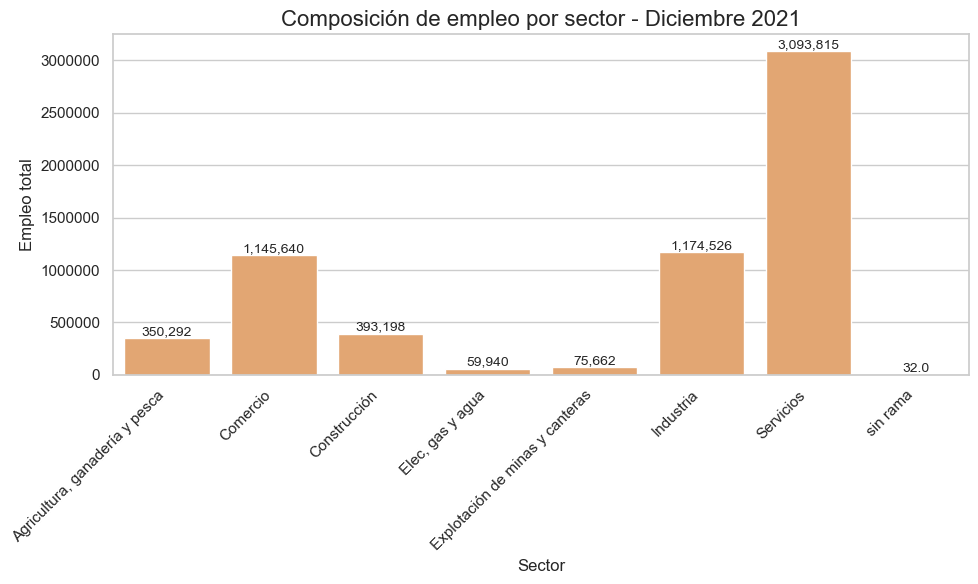

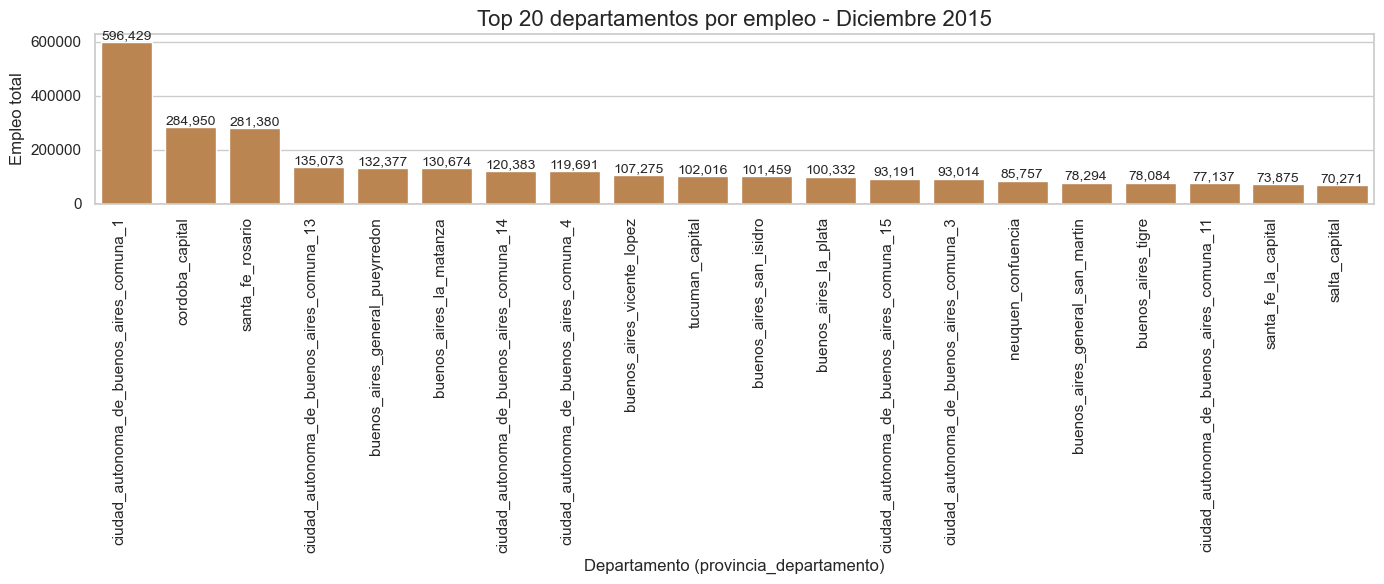

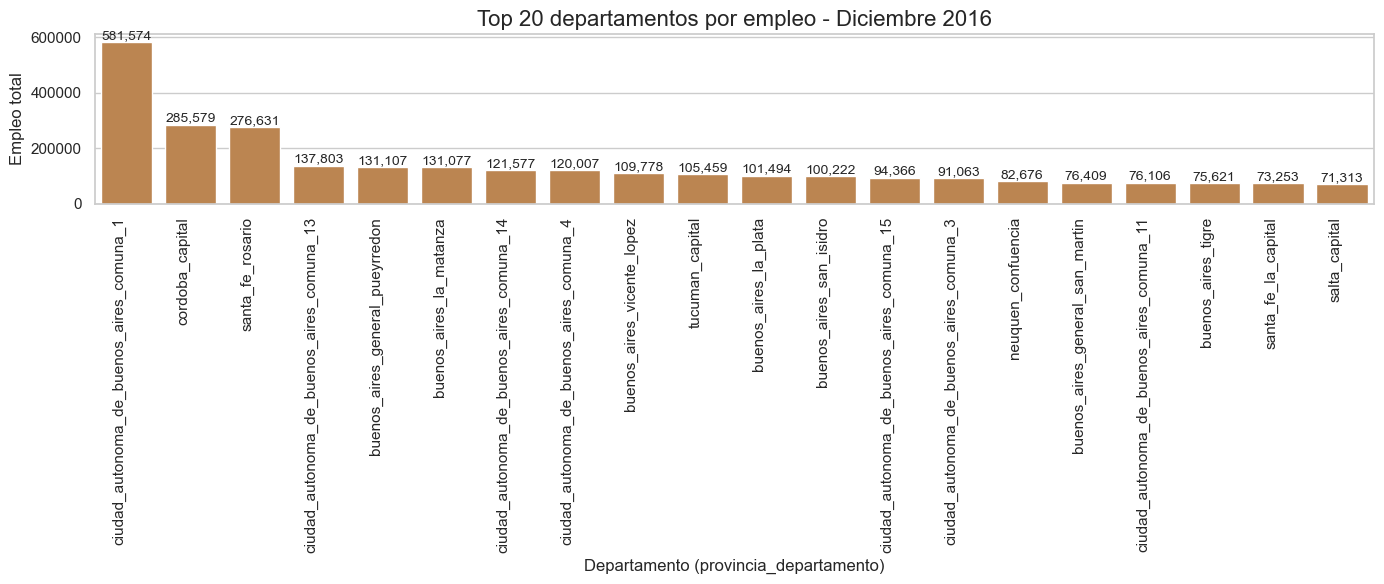

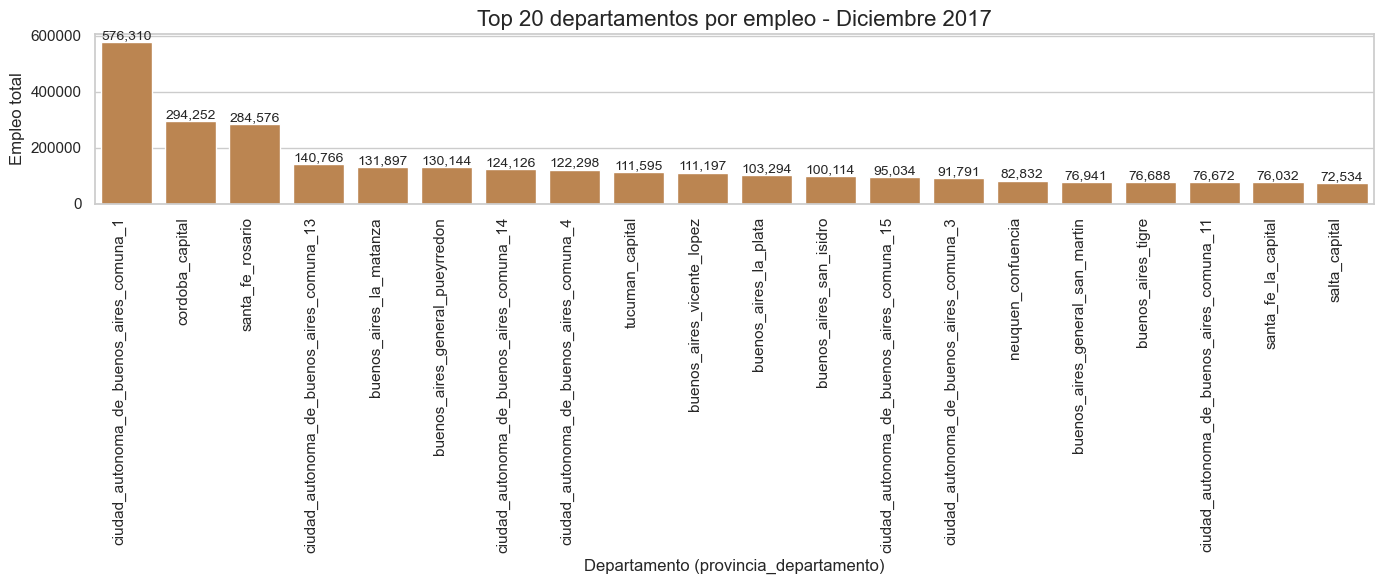

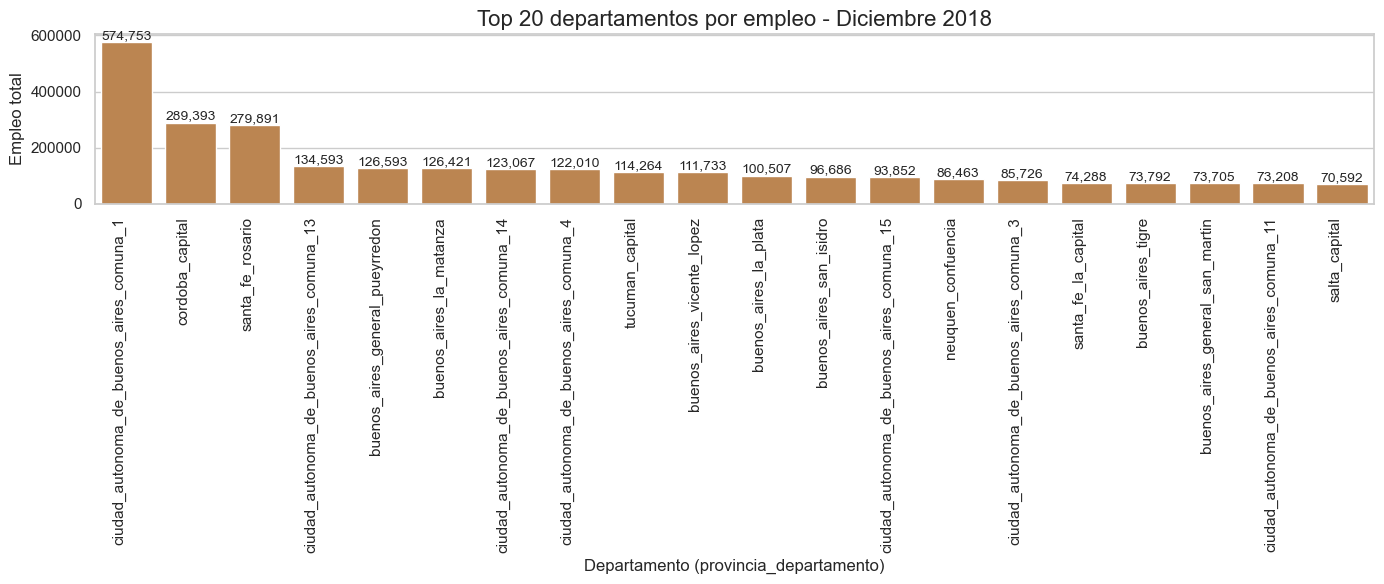

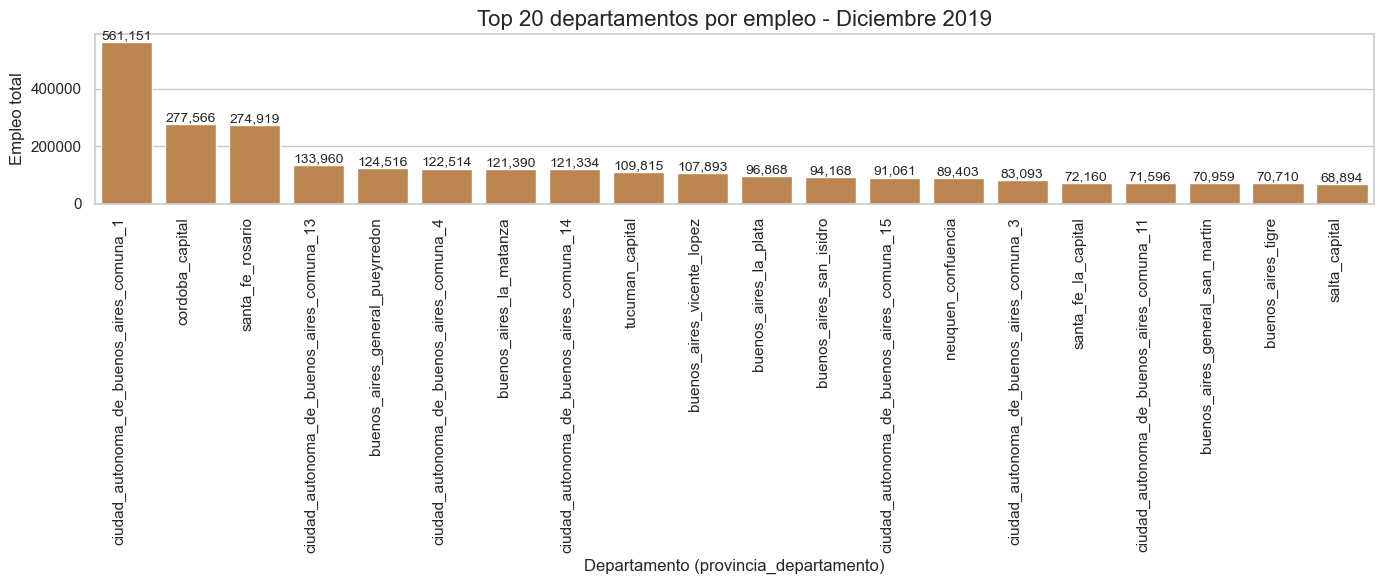

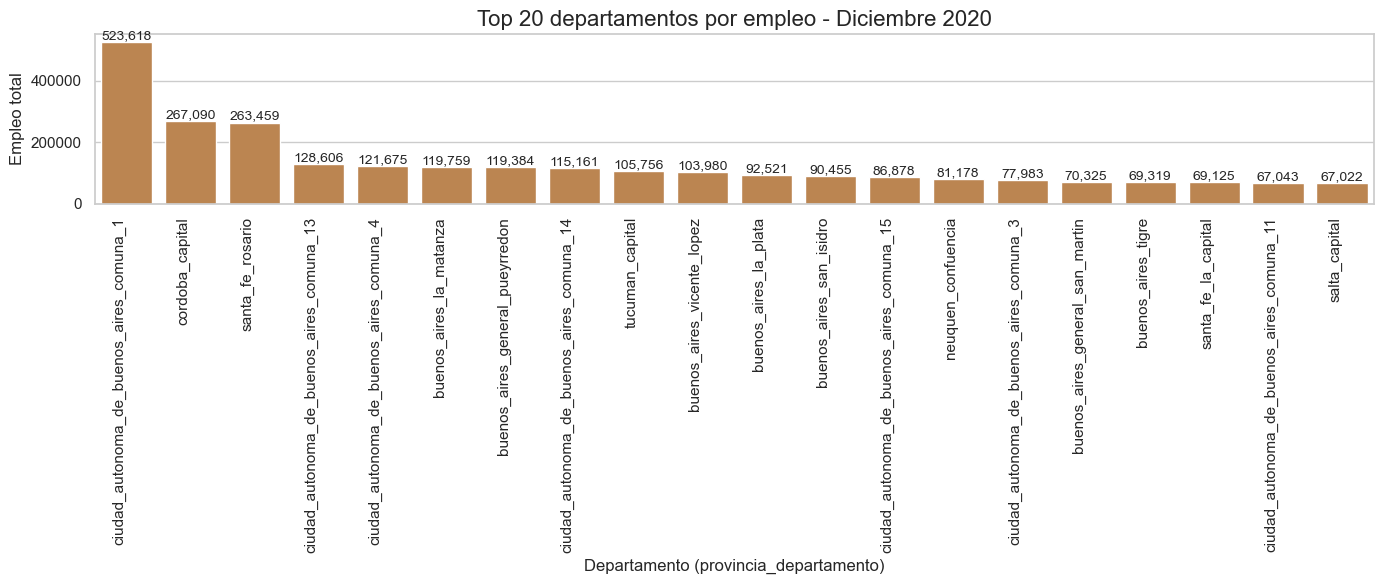

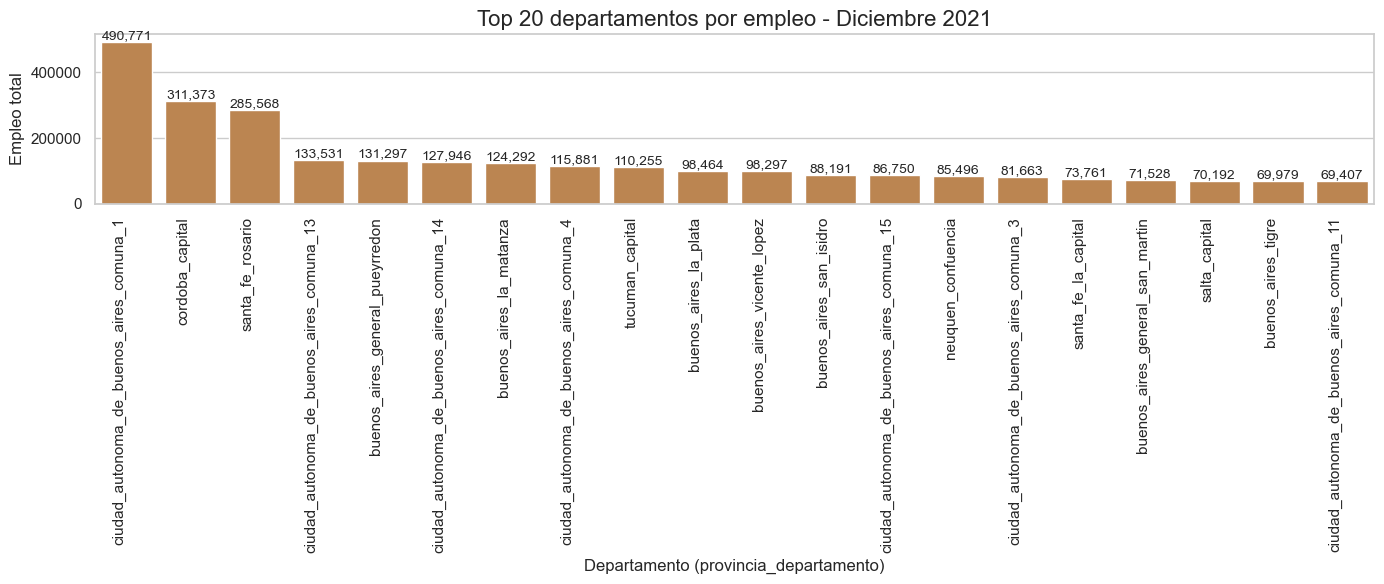

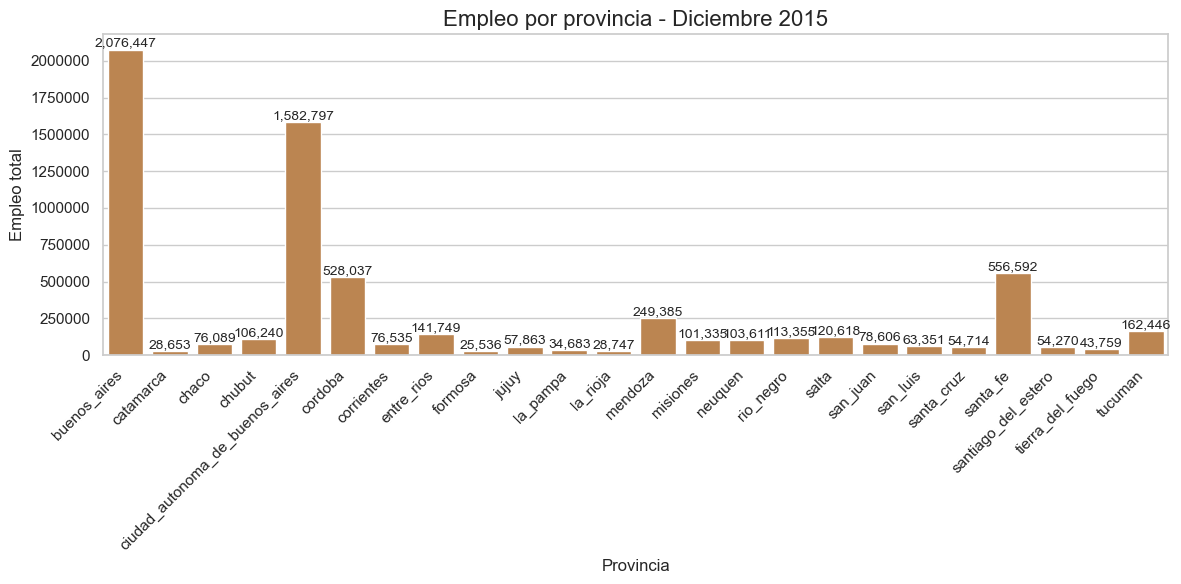

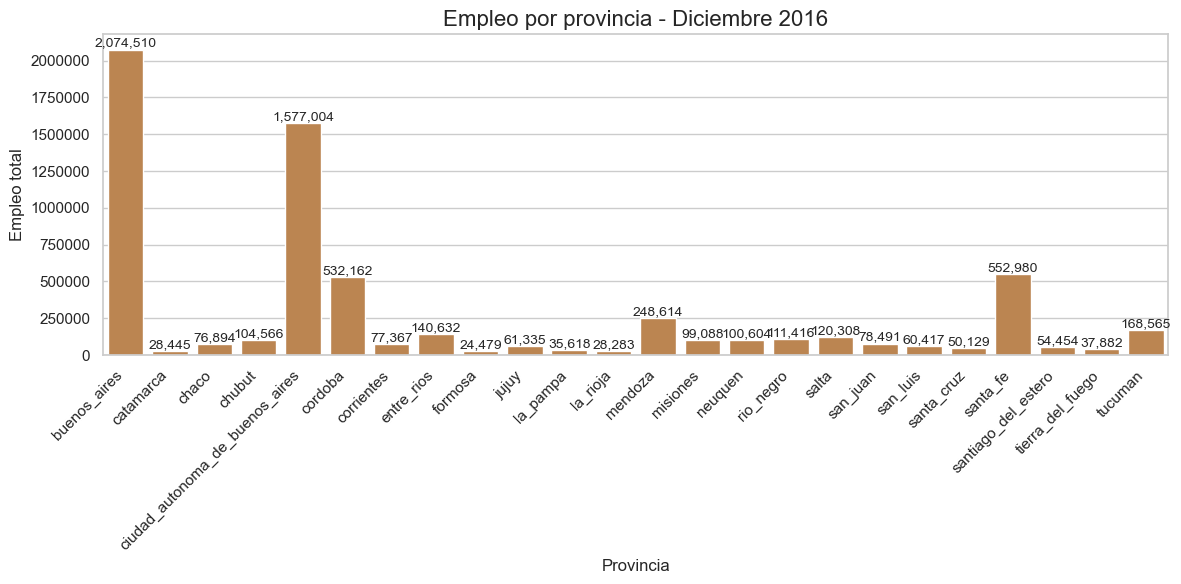

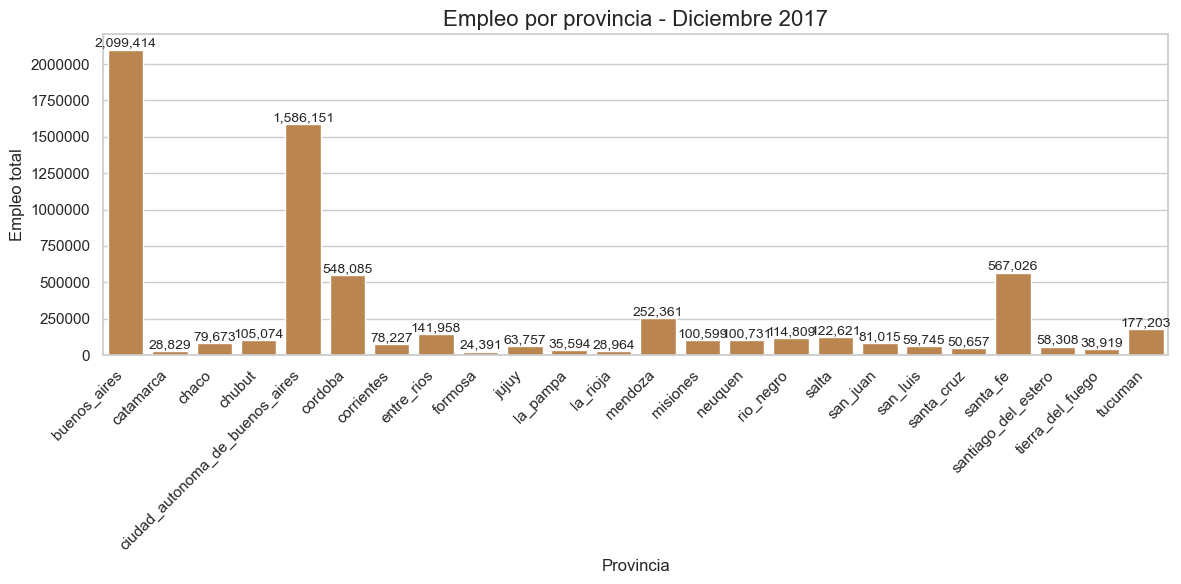

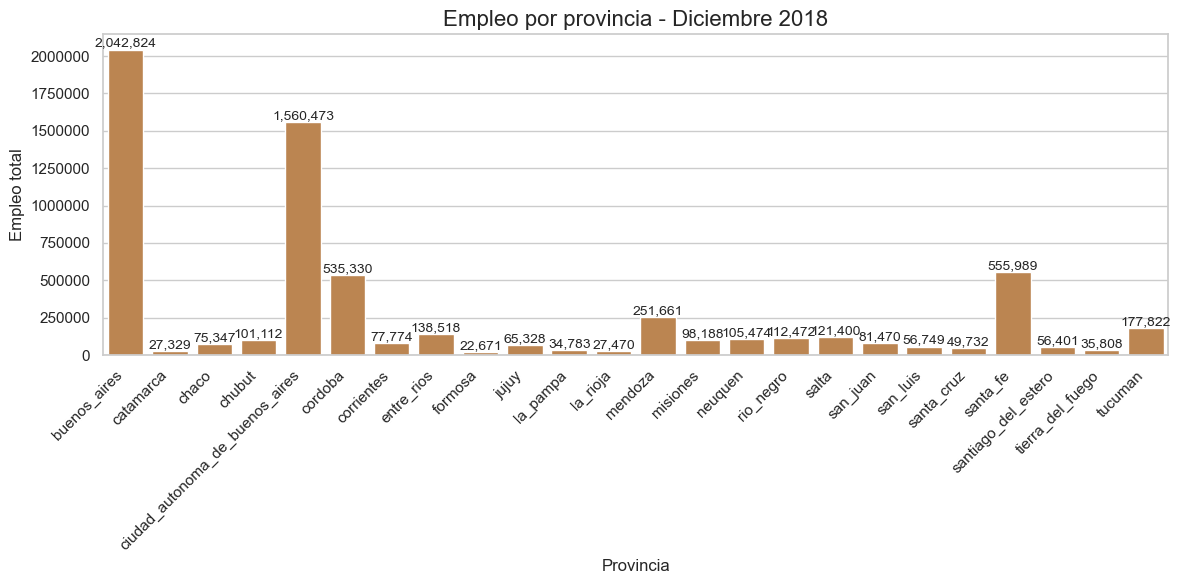

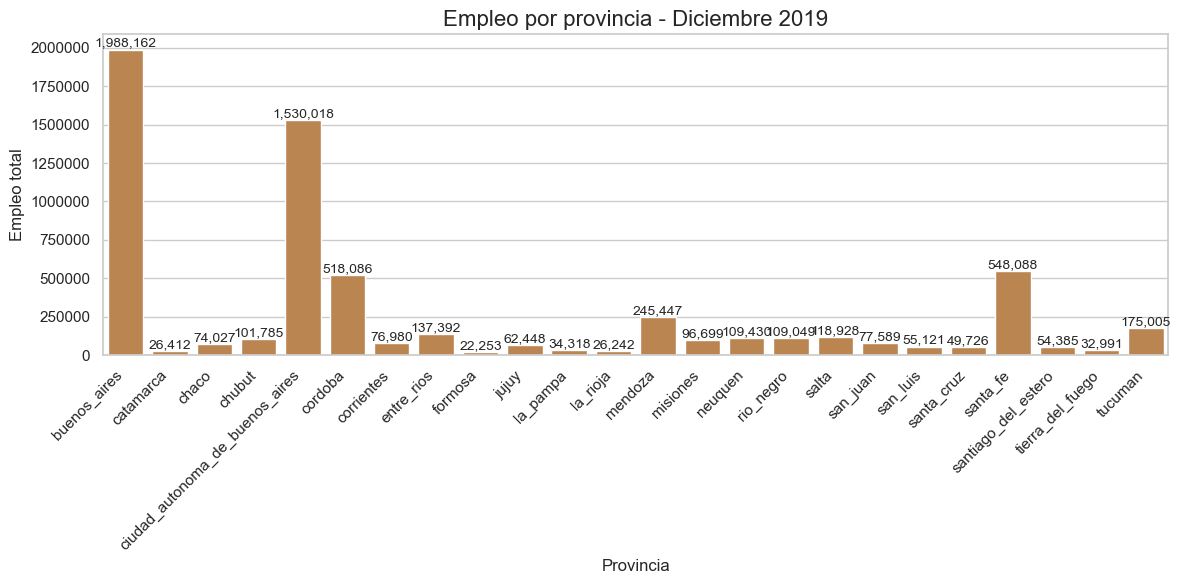

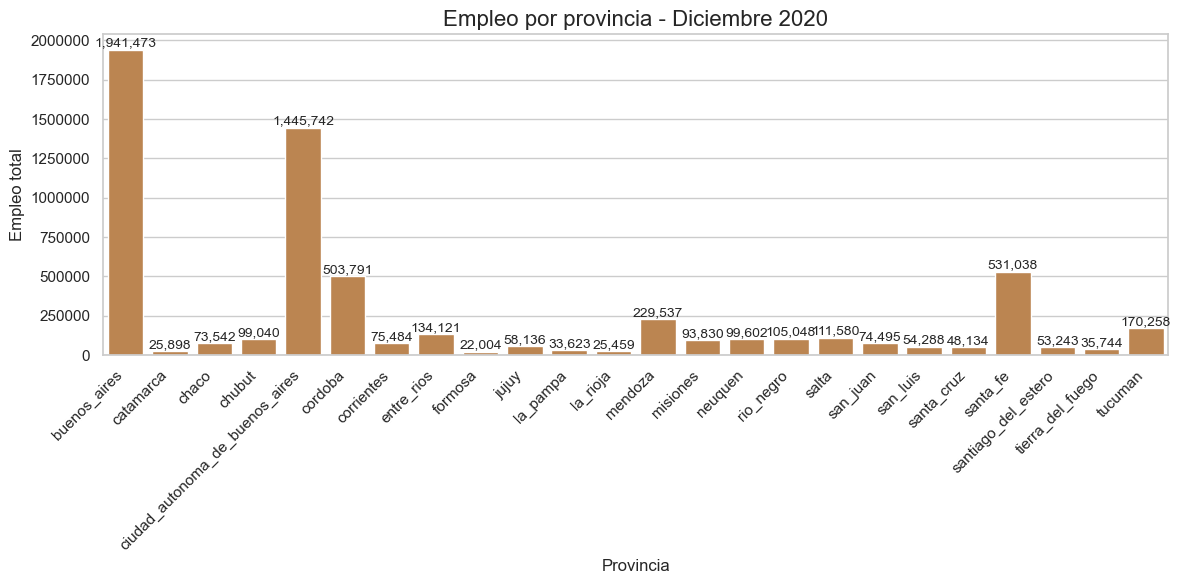

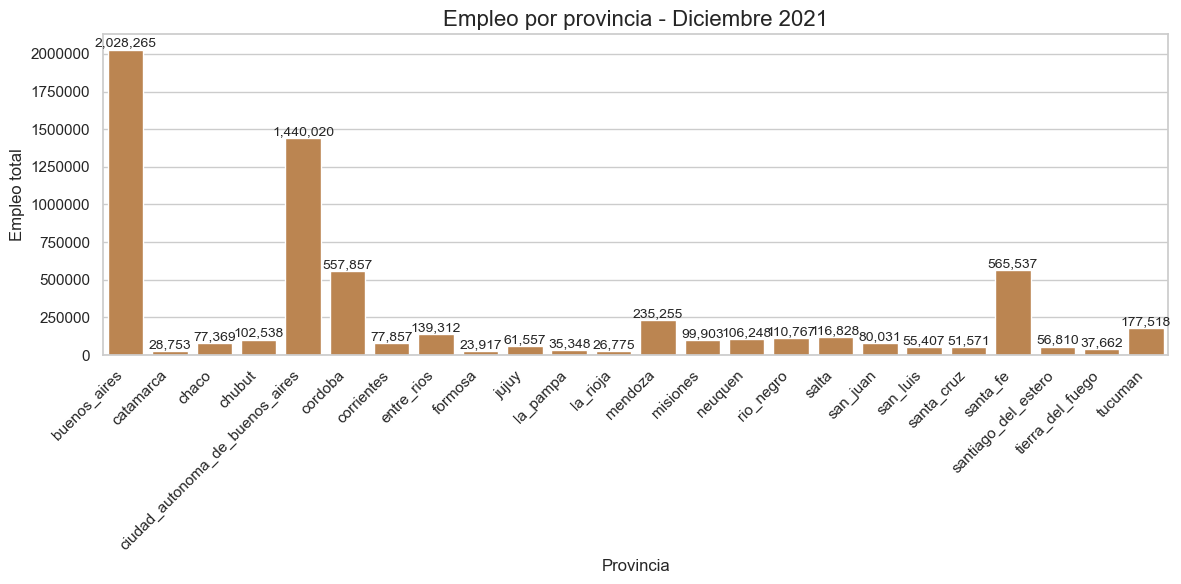

In [37]:
# ==============================================================
# Gráficos Q4 (Diciembre) usando provincia_completa
# ==============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 Extraer año y mes
empleo['anio'] = empleo['periodo'] // 100
empleo['mes'] = empleo['periodo'] % 100

# 🔹 Filtrar solo diciembre (último mes del Q4)
empleo_dic = empleo[empleo['mes'] == 12].copy()

# 🔹 Crear columna provincia_completa directamente
def extraer_provincia_completa(dep_id):
    dep_id = str(dep_id).lower()
    if dep_id.startswith("ciudad_autonoma"):
        return "ciudad_autonoma_de_buenos_aires"
    if dep_id.startswith("buenos_aires_"): return "buenos_aires"
    if dep_id.startswith("entre_rios_"): return "entre_rios"
    if dep_id.startswith("la_pampa_"): return "la_pampa"
    if dep_id.startswith("la_rioja_"): return "la_rioja"
    if dep_id.startswith("rio_negro_"): return "rio_negro"
    if dep_id.startswith("santa_cruz_"): return "santa_cruz"
    if dep_id.startswith("santa_fe_"): return "santa_fe"
    if dep_id.startswith("santiago_del_estero_"): return "santiago_del_estero"
    if dep_id.startswith("tierra_del_fuego_"): return "tierra_del_fuego"
    if dep_id.startswith("san_juan_"): return "san_juan"
    if dep_id.startswith("san_luis_"): return "san_luis"
    if dep_id.startswith("mendoza_"): return "mendoza"
    if dep_id.startswith("cordoba_"): return "cordoba"
    if dep_id.startswith("corrientes_"): return "corrientes"
    if dep_id.startswith("formosa_"): return "formosa"
    if dep_id.startswith("misiones_"): return "misiones"
    if dep_id.startswith("neuquen_"): return "neuquen"
    if dep_id.startswith("salta_"): return "salta"
    if dep_id.startswith("jujuy_"): return "jujuy"
    if dep_id.startswith("tucuman_"): return "tucuman"
    return dep_id.split("_")[0]

empleo_dic['provincia_completa'] = empleo_dic['DEP_ID'].apply(extraer_provincia_completa)

# 🔹 Función para agregar etiquetas horizontales
def add_labels_horizontal(ax):
    for p in ax.patches:
        height = p.get_height()
        label = f"{int(height):,}" if height >= 1000 else f"{height}"
        ax.annotate(label, (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=10, rotation=0)

# -------------------------------
# 1️⃣ Empleo por sector
# -------------------------------
sectores_dic = empleo_dic.groupby(['anio', 'sector'])['empleo'].sum().reset_index()

for year in sorted(sectores_dic['anio'].unique()):
    df_year = sectores_dic[sectores_dic['anio'] == year]
    plt.figure(figsize=(10,6))
    ax = sns.barplot(data=df_year, x='sector', y='empleo', color="sandybrown")
    add_labels_horizontal(ax)
    plt.title(f"Composición de empleo por sector - Diciembre {year}", fontsize=16)
    plt.xlabel("Sector", fontsize=12)
    plt.ylabel("Empleo total", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.ticklabel_format(style='plain', axis='y')
    plt.tight_layout()
    plt.show()

# -------------------------------
# 2️⃣ Top 20 departamentos por empleo
# -------------------------------
dept_dic = empleo_dic.groupby(['anio', 'DEP_ID', 'provincia_completa'])['empleo'].sum().reset_index()

for year in sorted(dept_dic['anio'].unique()):
    df_year = dept_dic[dept_dic['anio'] == year].sort_values('empleo', ascending=False).head(20)
    plt.figure(figsize=(14,6))
    ax = sns.barplot(data=df_year, x='DEP_ID', y='empleo', color="peru")
    add_labels_horizontal(ax)
    plt.title(f"Top 20 departamentos por empleo - Diciembre {year}", fontsize=16)
    plt.xlabel("Departamento (provincia_departamento)", fontsize=12)
    plt.ylabel("Empleo total", fontsize=12)
    plt.xticks(rotation=90, ha='right')
    plt.ticklabel_format(style='plain', axis='y')
    plt.tight_layout()
    plt.show()

# -------------------------------
# 3️⃣ Empleo por provincia
# -------------------------------
prov_dic_graf = dept_dic.groupby(['anio', 'provincia_completa'])['empleo'].sum().reset_index()

for year in sorted(prov_dic_graf['anio'].unique()):
    df_year = prov_dic_graf[prov_dic_graf['anio'] == year]
    plt.figure(figsize=(12,6))
    ax = sns.barplot(data=df_year, x='provincia_completa', y='empleo', color="peru")
    add_labels_horizontal(ax)
    plt.title(f"Empleo por provincia - Diciembre {year}", fontsize=16)
    plt.xlabel("Provincia", fontsize=12)
    plt.ylabel("Empleo total", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.ticklabel_format(style='plain', axis='y')
    plt.tight_layout()
    plt.show()


In [38]:
# ==============================================================
# Estadísticas descriptivas Q4 para gráficos (diciembre)
# ==============================================================

import pandas as pd
import numpy as np

# 🔹 Extraer año y mes
empleo['anio'] = empleo['periodo'] // 100
empleo['mes'] = empleo['periodo'] % 100

# 🔹 Filtrar solo diciembre (último mes del Q4)
empleo_dic = empleo[empleo['mes'] == 12].copy()

# 🔹 Agregar columna provincia_completa usando la función definida previamente
def extraer_provincia_completa(dep_id):
    dep_id = dep_id.lower()
    if dep_id.startswith("ciudad_autonoma"):
        return "ciudad_autonoma_de_buenos_aires"
    if dep_id.startswith("buenos_aires_"): return "buenos_aires"
    if dep_id.startswith("entre_rios_"): return "entre_rios"
    if dep_id.startswith("la_pampa_"): return "la_pampa"
    if dep_id.startswith("la_rioja_"): return "la_rioja"
    if dep_id.startswith("rio_negro_"): return "rio_negro"
    if dep_id.startswith("santa_cruz_"): return "santa_cruz"
    if dep_id.startswith("santa_fe_"): return "santa_fe"
    if dep_id.startswith("santiago_del_estero_"): return "santiago_del_estero"
    if dep_id.startswith("tierra_del_fuego_"): return "tierra_del_fuego"
    if dep_id.startswith("san_juan_"): return "san_juan"
    if dep_id.startswith("san_luis_"): return "san_luis"
    if dep_id.startswith("mendoza_"): return "mendoza"
    if dep_id.startswith("cordoba_"): return "cordoba"
    if dep_id.startswith("corrientes_"): return "corrientes"
    if dep_id.startswith("formosa_"): return "formosa"
    if dep_id.startswith("misiones_"): return "misiones"
    if dep_id.startswith("neuquen_"): return "neuquen"
    if dep_id.startswith("salta_"): return "salta"
    if dep_id.startswith("jujuy_"): return "jujuy"
    if dep_id.startswith("tucuman_"): return "tucuman"
    return dep_id.split("_")[0]

empleo_dic['provincia_completa'] = empleo_dic['DEP_ID'].apply(extraer_provincia_completa)

# -------------------------------
# 1️⃣ Composición empleo por sector
sectores_dic = empleo_dic.drop_duplicates(subset=['anio','depto_final','sector'])
sectores_stats = sectores_dic.groupby(['anio','sector'])['empleo'].agg(['count','sum','mean','min','max']).reset_index()
print("=== Estadísticas empleo por sector - Q4 ===")
print(sectores_stats.sort_values(['anio','sum'], ascending=[True, False]).head(20))

# -------------------------------
# 2️⃣ Top 20 departamentos por empleo
dept_dic = empleo_dic.drop_duplicates(subset=['anio','DEP_ID'])
dept_stats = dept_dic.groupby(['anio','DEP_ID','provincia_completa'])['empleo'].agg(['count','sum','mean','min','max']).reset_index()
print("\n=== Estadísticas Top departamentos por empleo - Q4 ===")
for year in sorted(dept_stats['anio'].unique()):
    print(f"\n--- {year} ---")
    display(dept_stats[dept_stats['anio']==year].sort_values('sum', ascending=False).head(20))

# -------------------------------
# 3️⃣ Empleo por provincia
prov_stats = empleo_dic.groupby(['anio','provincia_completa'])['empleo'].agg(['count','sum','mean','min','max']).reset_index()
print("\n=== Estadísticas empleo por provincia - Q4 ===")
for year in sorted(prov_stats['anio'].unique()):
    print(f"\n--- {year} ---")
    display(prov_stats[prov_stats['anio']==year].sort_values('sum', ascending=False))


=== Estadísticas empleo por sector - Q4 ===
    anio                           sector  count        sum         mean  \
6   2015                        Servicios    481  3096046.0  6436.686071   
5   2015                        Industria    404  1282501.0  3174.507426   
1   2015                         Comercio    483  1175171.0  2433.066253   
2   2015                     Construcción    333   428201.0  1285.888889   
0   2015   Agricultura, ganadería y pesca    471   347663.0   738.138004   
4   2015  Explotación de minas y canteras     71    75608.0  1064.901408   
3   2015                 Elec, gas y agua    181    59890.0   330.883978   
7   2015                         sin rama     18      338.0    18.777778   
14  2016                        Servicios    477  3109941.0  6519.792453   
13  2016                        Industria    399  1239506.0  3106.531328   
9   2016                         Comercio    483  1192905.0  2469.782609   
10  2016                     Construcción   

,anio,DEP_ID,provincia_completa,count,sum,mean,min,max
189,2015,ciudad_autonoma_de_buenos_aires_comuna_1,ciudad_autonoma_de_buenos_aires,1,449983.0,449983.0,449983.0,449983.0
206,2015,cordoba_capital,cordoba,1,155487.0,155487.0,155487.0,155487.0
465,2015,santa_fe_rosario,santa_fe,1,147848.0,147848.0,147848.0,147848.0
193,2015,ciudad_autonoma_de_buenos_aires_comuna_13,ciudad_autonoma_de_buenos_aires,1,93714.0,93714.0,93714.0,93714.0
194,2015,ciudad_autonoma_de_buenos_aires_comuna_14,ciudad_autonoma_de_buenos_aires,1,92924.0,92924.0,92924.0,92924.0
54,2015,buenos_aires_general_pueyrredon,buenos_aires,1,73214.0,73214.0,73214.0,73214.0
198,2015,ciudad_autonoma_de_buenos_aires_comuna_4,ciudad_autonoma_de_buenos_aires,1,68355.0,68355.0,68355.0,68355.0
197,2015,ciudad_autonoma_de_buenos_aires_comuna_3,ciudad_autonoma_de_buenos_aires,1,57638.0,57638.0,57638.0,57638.0
67,2015,buenos_aires_la_plata,buenos_aires,1,55733.0,55733.0,55733.0,55733.0
131,2015,buenos_aires_vicente_lopez,buenos_aires,1,55213.0,55213.0,55213.0,55213.0



--- 2016 ---


,anio,DEP_ID,provincia_completa,count,sum,mean,min,max
709,2016,ciudad_autonoma_de_buenos_aires_comuna_1,ciudad_autonoma_de_buenos_aires,1,440200.0,440200.0,440200.0,440200.0
726,2016,cordoba_capital,cordoba,1,157495.0,157495.0,157495.0,157495.0
985,2016,santa_fe_rosario,santa_fe,1,143752.0,143752.0,143752.0,143752.0
713,2016,ciudad_autonoma_de_buenos_aires_comuna_13,ciudad_autonoma_de_buenos_aires,1,95911.0,95911.0,95911.0,95911.0
714,2016,ciudad_autonoma_de_buenos_aires_comuna_14,ciudad_autonoma_de_buenos_aires,1,94774.0,94774.0,94774.0,94774.0
574,2016,buenos_aires_general_pueyrredon,buenos_aires,1,72374.0,72374.0,72374.0,72374.0
718,2016,ciudad_autonoma_de_buenos_aires_comuna_4,ciudad_autonoma_de_buenos_aires,1,69353.0,69353.0,69353.0,69353.0
587,2016,buenos_aires_la_plata,buenos_aires,1,57014.0,57014.0,57014.0,57014.0
651,2016,buenos_aires_vicente_lopez,buenos_aires,1,56651.0,56651.0,56651.0,56651.0
717,2016,ciudad_autonoma_de_buenos_aires_comuna_3,ciudad_autonoma_de_buenos_aires,1,55810.0,55810.0,55810.0,55810.0



--- 2017 ---


...

,anio,provincia_completa,count,sum,mean,min,max
96,2019,buenos_aires,722,1988162.0,2753.686981,4.0,68865.0
100,2019,ciudad_autonoma_de_buenos_aires,92,1530018.0,16630.630435,7.0,429019.0
116,2019,santa_fe,106,548088.0,5170.641509,22.0,146993.0
101,2019,cordoba,134,518086.0,3866.313433,5.0,159241.0
108,2019,mendoza,100,245447.0,2454.470000,10.0,36933.0
119,2019,tucuman,81,175005.0,2160.555556,3.0,56518.0
103,2019,entre_rios,93,137392.0,1477.333333,12.0,20879.0
112,2019,salta,84,118928.0,1415.809524,5.0,37884.0
110,2019,neuquen,62,109430.0,1765.000000,7.0,39399.0
111,2019,rio_negro,55,109049.0,1982.709091,5.0,17619.0



--- 2020 ---


,anio,provincia_completa,count,sum,mean,min,max
120,2020,buenos_aires,709,1941473.0,2738.325811,3.0,64779.0
124,2020,ciudad_autonoma_de_buenos_aires,93,1445742.0,15545.612903,4.0,406280.0
140,2020,santa_fe,106,531038.0,5009.792453,4.0,138822.0
125,2020,cordoba,134,503791.0,3759.634328,5.0,154341.0
132,2020,mendoza,100,229537.0,2295.370000,9.0,34063.0
143,2020,tucuman,79,170258.0,2155.164557,3.0,54635.0
127,2020,entre_rios,93,134121.0,1442.161290,22.0,20382.0
136,2020,salta,84,111580.0,1328.333333,5.0,36662.0
135,2020,rio_negro,53,105048.0,1982.037736,4.0,17064.0
134,2020,neuquen,60,99602.0,1660.033333,5.0,36764.0



--- 2021 ---


,anio,provincia_completa,count,sum,mean,min,max
144,2021,buenos_aires,709,2028265.0,2860.740480,3.0,72797.0
148,2021,ciudad_autonoma_de_buenos_aires,90,1440020.0,16000.222222,3.0,376693.0
164,2021,santa_fe,106,565537.0,5335.254717,4.0,149419.0
149,2021,cordoba,133,557857.0,4194.413534,4.0,184388.0
156,2021,mendoza,100,235255.0,2352.550000,17.0,33333.0
167,2021,tucuman,78,177518.0,2275.871795,9.0,56256.0
151,2021,entre_rios,92,139312.0,1514.260870,20.0,21079.0
160,2021,salta,84,116828.0,1390.809524,5.0,38175.0
159,2021,rio_negro,54,110767.0,2051.240741,4.0,18058.0
158,2021,neuquen,59,106248.0,1800.813559,12.0,37614.0


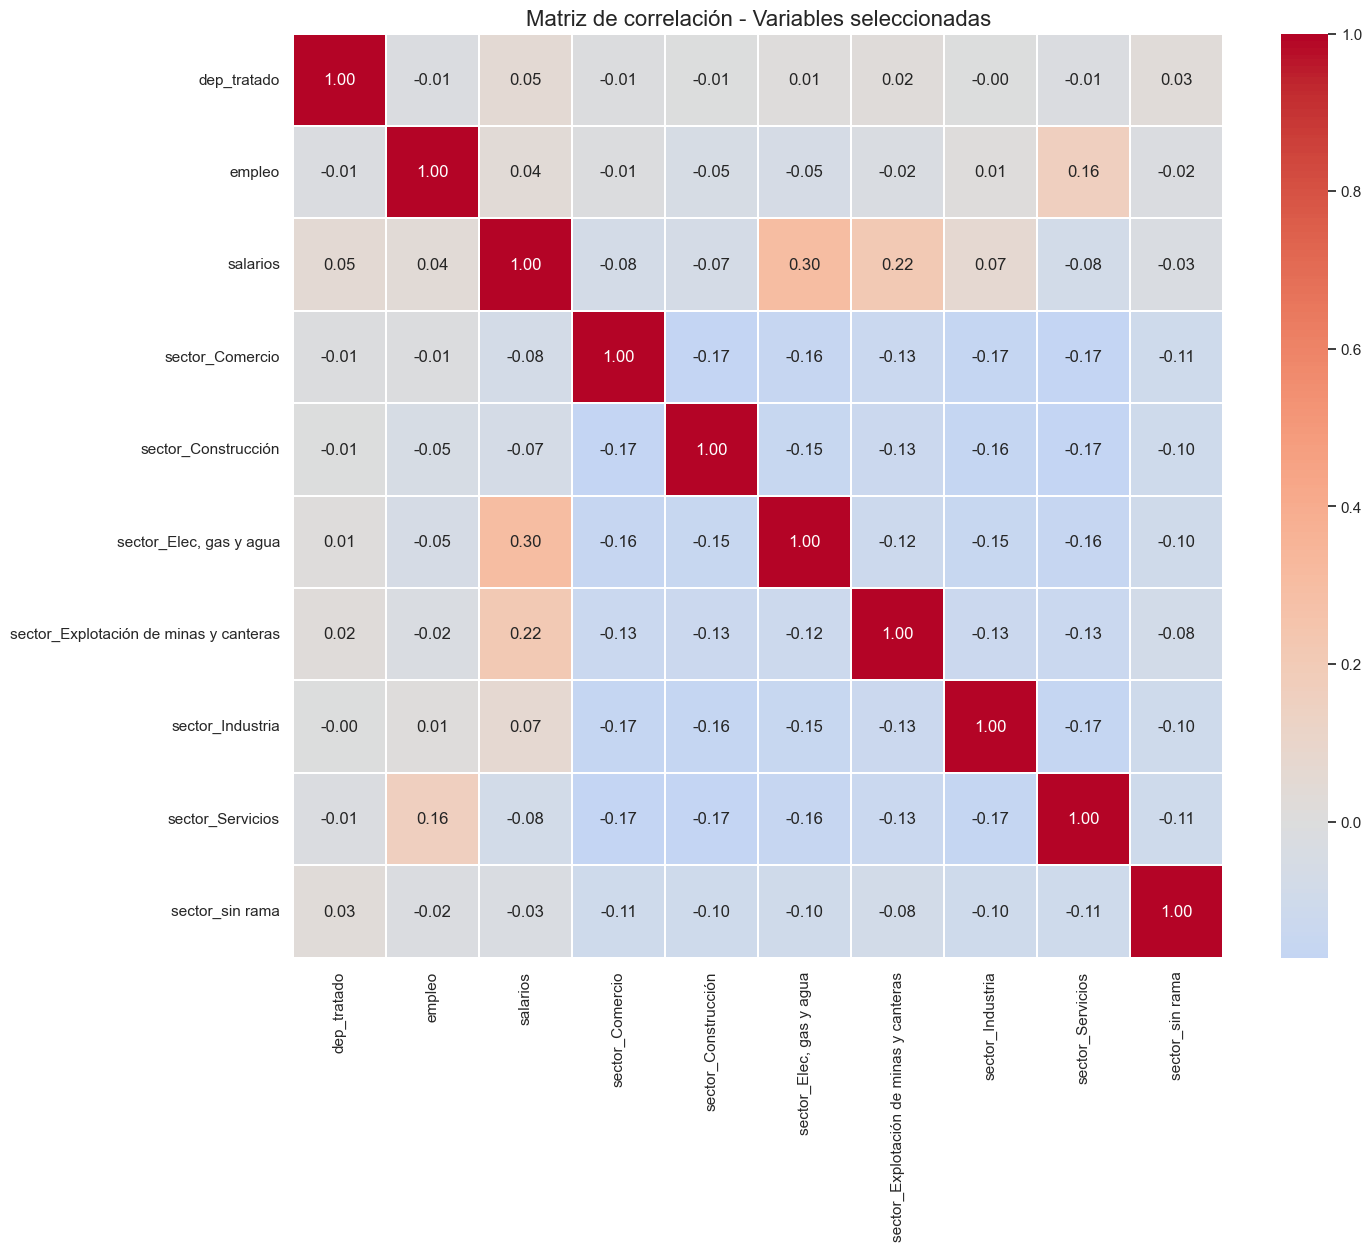

In [39]:
# ==============================================================
# Matriz de correlación con variables categóricas y numéricas 
# ==============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 🔹 Copiar base para trabajar
df_corr = empleo_dic.copy()

# 🔹 Seleccionar variables de interés
vars_corr = ['dep_tratado', 'sector', 'empleo', 'salarios']
df_corr = df_corr[vars_corr]

# 🔹 Crear variables dummy para las categóricas
categorical_vars = ['sector']
df_dummies = pd.get_dummies(df_corr[categorical_vars], prefix=categorical_vars, drop_first=True)

# 🔹 Combinar con las variables numéricas
numeric_vars = ['dep_tratado', 'empleo', 'salarios']
df_corr_final = pd.concat([df_corr[numeric_vars], df_dummies], axis=1)

# 🔹 Matriz de correlación
corr_matrix = df_corr_final.corr()

# 🔹 Visualización
plt.figure(figsize=(15,12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, linewidths=0.1, annot=True, fmt=".2f")
plt.title("Matriz de correlación - Variables seleccionadas", fontsize=16)
plt.show()


In [40]:
# ==============================================================
# Exportar matriz de correlación a Excel
# ==============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 🔹 Copiar base para trabajar
df_corr = empleo_dic.copy()

# 🔹 Seleccionar variables de interés (sin 'periodo')
vars_corr = ['dep_tratado', 'sector', 'empleo', 'salarios']
df_corr = df_corr[vars_corr]

# 🔹 Crear variables dummy para las categóricas
categorical_vars = ['sector']
df_dummies = pd.get_dummies(df_corr[categorical_vars], prefix=categorical_vars, drop_first=True)

# 🔹 Combinar con las variables numéricas
numeric_vars = ['dep_tratado', 'empleo', 'salarios']
df_corr_final = pd.concat([df_corr[numeric_vars], df_dummies], axis=1)

# 🔹 Matriz de correlación
corr_matrix = df_corr_final.corr()

# 🔹 Guardar en Excel
corr_matrix.to_excel("matriz_correlacion_variables.xlsx", sheet_name="Correlaciones")

print("✅ Matriz de correlación exportada a 'matriz_correlacion_variables.xlsx'")


✅ Matriz de correlación exportada a 'matriz_correlacion_variables.xlsx'


In [41]:
import numpy as np
import pandas as pd

# Asegurar que 'periodo' sea numérico
empleo['periodo'] = pd.to_numeric(empleo['periodo'], errors='coerce')

# Crear variables de año y mes
empleo['anio'] = np.floor(empleo['periodo'] / 100).astype(int)
empleo['mes'] = (empleo['periodo'] % 100).astype(int)

# Crear variable trimestre (como 2015Q1, 2015Q2, etc.)
empleo['trimestre'] = empleo.apply(lambda x: f"{x['anio']}Q{int(np.ceil(x['mes'] / 3))}", axis=1)

# Verificar
empleo[['periodo', 'anio', 'mes', 'trimestre']].head()


,periodo,anio,mes,trimestre
0,201501,2015,1,2015Q1
1,201502,2015,2,2015Q1
2,201503,2015,3,2015Q1
3,201504,2015,4,2015Q2
4,201505,2015,5,2015Q2


In [42]:
print(empleo.columns.tolist())

['provi_id', 'provincia', 'depto_final', 'departamento', 'sector', 'periodo', 'empleo', 'salarios', 'prov_clean', 'dep_clean', 'DEP_ID', 'dep_tratado', 'anio', 'mes', 'trimestre']


In [46]:
print("=== prov_clean (primeras 20) ===")
print(empleo['prov_clean'].dropna().unique()[:20])

print("\n=== provincia_completa (primeras 20) ===")
print(empleo['provincia_completa'].dropna().unique()[:20])

print("\n=== Comparación rápida ===")
print("Cantidad de categorías prov_clean:", empleo['prov_clean'].nunique())
print("Cantidad de categorías provincia_completa:", empleo['provincia_completa'].nunique())


=== prov_clean (primeras 20) ===
['ciudad autonoma de buenos aires' 'buenos aires' 'catamarca' 'cordoba'
 'corrientes' 'chaco' 'chubut' 'entre rios' 'formosa' 'jujuy' 'la pampa'
 'la rioja' 'mendoza' 'misiones' 'neuquen' 'rio negro' 'salta' 'san juan'
 'san luis' 'santa cruz']

=== provincia_completa (primeras 20) ===
['ciudad_autonoma_de_buenos_aires' 'buenos_aires' 'catamarca' 'cordoba'
 'corrientes' 'chaco' 'chubut' 'entre_rios' 'formosa' 'jujuy' 'la_pampa'
 'la_rioja' 'mendoza' 'misiones' 'neuquen' 'rio_negro' 'salta' 'san_juan'
 'san_luis' 'santa_cruz']

=== Comparación rápida ===
Cantidad de categorías prov_clean: 24
Cantidad de categorías provincia_completa: 24


In [47]:
# ==============================================================
# Estadísticas descriptivas y visualizaciones del empleo
# ==============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

# --------------------------------------------------------------
# 1️⃣ Limpieza y creación de variables
# --------------------------------------------------------------
empleo['empleo'] = pd.to_numeric(empleo['empleo'], errors='coerce')
empleo['ln_empleo'] = np.log(empleo['empleo'] + 1)  # evitar log(0)

# Extraer año, mes y trimestre del periodo
empleo['anio'] = (empleo['periodo'] // 100).astype(int)
empleo['mes'] = (empleo['periodo'] % 100).astype(int)
empleo['trimestre'] = empleo['anio'].astype(str) + 'Q' + ((empleo['mes'] - 1)//3 + 1).astype(str)

# --------------------------------------------------------------
# 2️⃣ Estadísticas descriptivas
# --------------------------------------------------------------
print("=== Estadísticas descriptivas generales ===")
print(empleo[['empleo', 'ln_empleo', 'salarios']].describe())

print("\n=== Promedios por dep_tratado ===")
print(empleo.groupby('dep_tratado')[['empleo', 'ln_empleo', 'salarios']].mean())

print("\n=== Promedios por sector ===")
print(empleo.groupby('sector')[['empleo', 'ln_empleo', 'salarios']].mean())

print("\n=== Promedios por provincia (prov_clean) ===")
print(empleo.groupby('prov_clean')[['empleo', 'ln_empleo', 'salarios']].mean())

# --------------------------------------------------------------
# 3️⃣ Tablas de frecuencia
# --------------------------------------------------------------
def frecuencia(df, columna):
    tab = df[columna].value_counts().sort_index().reset_index()
    tab.columns = [columna, 'Frecuencia']
    tab['Porcentaje'] = (tab['Frecuencia'] / tab['Frecuencia'].sum()) * 100
    tab['Acumulado'] = tab['Porcentaje'].cumsum()
    return tab

for col in ['dep_tratado', 'sector', 'prov_clean', 'trimestre']:
    print(f"\n=== Frecuencia {col} ===")
    print(frecuencia(empleo, col))

# --------------------------------------------------------------
# 4️⃣ Estadísticas específicas para gráficos
# --------------------------------------------------------------
empleo_dep = empleo.groupby('dep_tratado')[['empleo', 'ln_empleo']].describe()
empleo_sector = empleo.groupby('sector')[['empleo', 'ln_empleo']].describe()
empleo_trimestre = empleo.groupby('trimestre')[['empleo', 'ln_empleo']].describe()
empleo_prov = empleo.groupby('prov_clean')[['empleo', 'ln_empleo']].describe()

print("\n=== Estadísticas por dep_tratado ===")
print(empleo_dep)

print("\n=== Estadísticas por sector ===")
print(empleo_sector)

print("\n=== Estadísticas por trimestre ===")
print(empleo_trimestre)

print("\n=== Estadísticas por provincia ===")
print(empleo_prov)

# --------------------------------------------------------------
# 5️⃣ Visualizaciones
# --------------------------------------------------------------
sns.set(style="whitegrid")

with PdfPages("graficos_empleo_v2.pdf") as pdf_file:

    # Countplot por trimestre
    plt.figure(figsize=(14,6))
    sns.countplot(x='trimestre', data=empleo, color='mediumslateblue')
    plt.xticks(rotation=45)
    plt.title("Frecuencia de registros por trimestre", fontsize=16)
    plt.xlabel("Trimestre")
    plt.ylabel("Cantidad de observaciones")
    plt.tight_layout()
    plt.savefig("empleo_frecuencia_trimestre_v2.png", dpi=300, bbox_inches='tight')
    pdf_file.savefig()
    plt.close()

    # Boxplot por dep_tratado
    plt.figure(figsize=(10,6))
    sns.boxplot(x='dep_tratado', y='empleo', data=empleo, color='lightgreen')
    plt.yscale('log')
    plt.title("Distribución de empleo por dep_tratado (escala log)", fontsize=16)
    plt.xlabel("dep_tratado")
    plt.ylabel("Empleo (escala log)")

    stats_dep = empleo.groupby('dep_tratado')['empleo'].agg(['mean', 'median'])
    for i, (idx, row) in enumerate(stats_dep.iterrows()):
        plt.text(i, row['median'], f"Mediana: {int(row['median'])}", ha='center', va='bottom', fontsize=9)
        plt.text(i, row['mean'], f"Media: {int(row['mean'])}", ha='center', va='top', fontsize=9, color='darkgreen')

    plt.tight_layout()
    plt.savefig("empleo_dep_tratado_etiquetas_v2.png", dpi=300, bbox_inches='tight')
    pdf_file.savefig()
    plt.close()

print("✅ Bloque corregido y listo para correr")


=== Estadísticas descriptivas generales ===
              empleo      ln_empleo      salarios
count  203148.000000  203148.000000  2.031480e+05
mean     2627.267180       6.036650  3.748953e+04
std     11738.590369       1.890658  3.701618e+04
min         3.000000       1.386294  1.227500e+03
25%       111.000000       4.718499  1.492201e+04
50%       379.000000       5.940171  2.590000e+04
75%      1449.000000       7.279319  4.757323e+04
max    450252.000000      13.017565  1.289383e+06

=== Promedios por dep_tratado ===
                  empleo  ln_empleo      salarios
dep_tratado                                      
0            2696.014936   5.949331  36700.981191
1            2297.340356   6.455700  41273.875045

=== Promedios por sector ===
                                      empleo  ln_empleo      salarios
sector                                                               
Agricultura, ganadería y pesca    758.238545   5.726628  27065.601599
Comercio                       

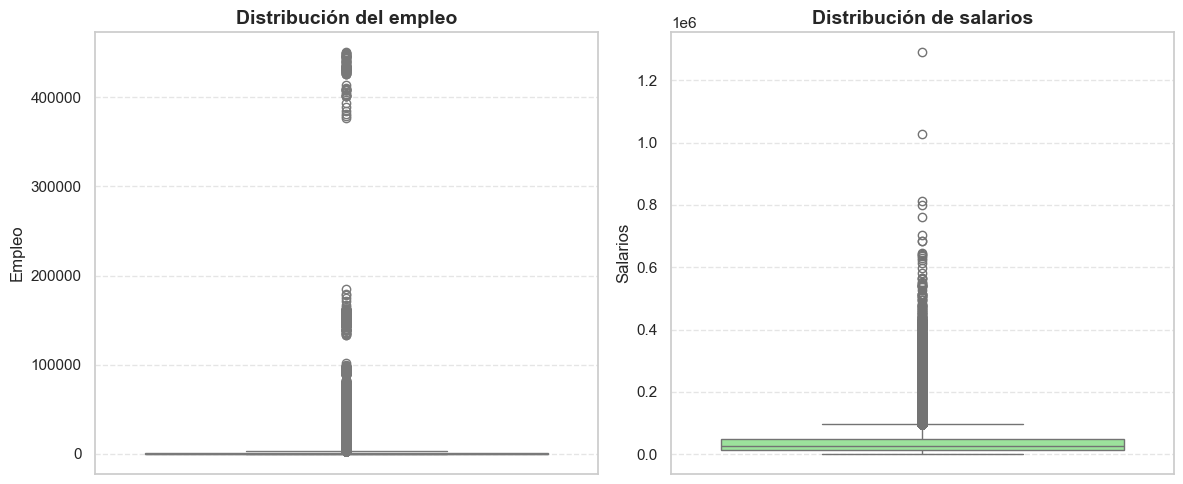

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo
sns.set(style="whitegrid")

# Figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot de empleo
sns.boxplot(y='empleo', data=empleo, ax=axes[0], color='lightblue')
axes[0].set_title("Distribución del empleo", fontsize=14, weight='bold')
axes[0].set_ylabel("Empleo")
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Boxplot de salarios
sns.boxplot(y='salarios', data=empleo, ax=axes[1], color='lightgreen')
axes[1].set_title("Distribución de salarios", fontsize=14, weight='bold')
axes[1].set_ylabel("Salarios")
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [49]:
# ===============================================================
# 🧱 1. Preparar base provincial para el modelo RenovAr
# Objetivo: obtener una fila por provincia con empleo y salarios promedio 2016–2019
# ===============================================================

import pandas as pd
import numpy as np

# ---------------------------------------------------------------
# 🔹 Aseguramos que las variables están en formato correcto
# ---------------------------------------------------------------
empleo['empleo'] = pd.to_numeric(empleo['empleo'], errors='coerce')
empleo['salarios'] = pd.to_numeric(empleo['salarios'], errors='coerce')

# Crear año si aún no existe
if 'anio' not in empleo.columns:
    empleo['anio'] = (empleo['periodo'] // 100).astype(int)

# ---------------------------------------------------------------
# 🔹 1. Filtrar período relevante (2016–2019)
# Solo usamos datos socioeconómicos del período de adjudicación RenovAr
# ---------------------------------------------------------------
empleo_filt = empleo[empleo['anio'].between(2016, 2019)].copy()

print("Registros originales:", len(empleo))
print("Registros 2016–2019:", len(empleo_filt))

# ---------------------------------------------------------------
# 🔹 2. Agregar empleo promedio por provincia
# ---------------------------------------------------------------
empleo_prov = (
    empleo_filt.groupby('provincia_completa')['empleo']
    .mean()
    .reset_index()
    .rename(columns={'empleo': 'empleo_prom'})
)

# ---------------------------------------------------------------
# 🔹 3. Agregar salario promedio por provincia
# ---------------------------------------------------------------
salarios_prov = (
    empleo_filt.groupby('provincia_completa')['salarios']
    .mean()
    .reset_index()
    .rename(columns={'salarios': 'salario_prom'})
)

# ---------------------------------------------------------------
# 🔹 4. Agregar log-empleo (útil para modelos)
# ---------------------------------------------------------------
empleo_filt['ln_empleo'] = np.log(empleo_filt['empleo'] + 1)

ln_empleo_prom_prov = (
    empleo_filt.groupby('provincia_completa')['ln_empleo']
    .mean()
    .reset_index()
    .rename(columns={'ln_empleo': 'ln_empleo_prom'})
)

# ---------------------------------------------------------------
# 🔹 5. Combinar todo en una base provincial única
# ---------------------------------------------------------------
base_prov = (
    empleo_prov
    .merge(salarios_prov, on='provincia_completa', how='inner')
    .merge(ln_empleo_prom_prov, on='provincia_completa', how='inner')
)

# ---------------------------------------------------------------
# 🔹 6. Resultado final
# Una fila por provincia, lista para integrar con EPH + variable tratada
# ---------------------------------------------------------------
print("\n=== BASE PROVINCIAL LISTA ===")
print(base_prov.head())

print("\nCantidad de provincias:", len(base_prov))


Registros originales: 293496
Registros 2016–2019: 167712

=== BASE PROVINCIAL LISTA ===
                provincia_completa   empleo_prom  salario_prom  ln_empleo_prom
0                     buenos_aires   2861.950632  30038.444987        6.350851
1                        catamarca    487.167906  21514.547931        4.959206
2                            chaco    817.682162  20737.776779        5.312202
3                           chubut   1670.553578  37134.262556        5.599662
4  ciudad_autonoma_de_buenos_aires  16933.667042  35591.824914        8.001135

Cantidad de provincias: 24


In [55]:
# 1. Limpieza preventiva: Si base_prov ya tiene la columna vieja (la incorrecta), la borramos
if 'provincia_tratada' in base_prov.columns:
    base_prov = base_prov.drop(columns=['provincia_tratada'])

# 2. Creamos la variable target CORRECTA desde cero
target_provincial = (
    empleo_filt.groupby('provincia_completa')['dep_tratado']
    .max()
    .reset_index()
    .rename(columns={'dep_tratado': 'provincia_tratada'})
)

# 3. Unimos (ahora sí, sin conflictos de nombres)
base_prov_final = base_prov.merge(target_provincial, on='provincia_completa', how='left')

# 4. Rellenamos nulos con 0 (por si alguna provincia no tuviera datos en employment_filt, aunque es raro)
base_prov_final['provincia_tratada'] = base_prov_final['provincia_tratada'].fillna(0).astype(int)

# ---------------------------------------------------------------
# 🔹 Verificación
# ---------------------------------------------------------------
print("Columnas actuales:", base_prov_final.columns.tolist())

print("\n=== VERIFICACIÓN DE PROVINCIAS CRÍTICAS ===")
provincias_check = ['santa_fe', 'chaco', 'entre_rios', 'formosa']
# Ahora debería funcionar
print(base_prov_final[base_prov_final['provincia_completa'].isin(provincias_check)][['provincia_completa', 'provincia_tratada']])


# 1. Filtra el DataFrame final donde la variable objetivo es 1
provincias_tratadas_df = base_prov_final[base_prov_final['provincia_tratada'] == 1].copy()

# 2. Crea la lista de nombres
lista_provincias_tratadas = sorted(provincias_tratadas_df['provincia_completa'].tolist())

print("\n=== LISTADO FINAL DE PROVINCIAS TRATADAS (Target = 1) ===")
for provincia in lista_provincias_tratadas:
    print(f"* {provincia.replace('_', ' ').title()}")

print(f"\nTotal de provincias tratadas: {len(lista_provincias_tratadas)} (de 24 posibles)")



Columnas actuales: ['provincia_completa', 'empleo_prom', 'salario_prom', 'ln_empleo_prom', 'provincia_tratada']

=== VERIFICACIÓN DE PROVINCIAS CRÍTICAS ===
   provincia_completa  provincia_tratada
2               chaco                  1
7          entre_rios                  0
8             formosa                  1
20           santa_fe                  1

=== LISTADO FINAL DE PROVINCIAS TRATADAS (Target = 1) ===
* Buenos Aires
* Catamarca
* Chaco
* Chubut
* Cordoba
* Corrientes
* Formosa
* Jujuy
* La Pampa
* La Rioja
* Mendoza
* Misiones
* Neuquen
* Rio Negro
* Salta
* San Juan
* San Luis
* Santa Cruz
* Santa Fe
* Santiago Del Estero
* Tucuman

Total de provincias tratadas: 21 (de 24 posibles)


In [58]:
# Suponiendo que 'empleo_filt' (DataFrame filtrado 2016-2019 con 'dep_tratado')
# y 'base_prov' (DataFrame con empleo_prom, salario_prom, ln_empleo_prom)
# están disponibles en memoria.

# ==============================================================
# B) Crear variable objetivo Y: provincia_tratada (CORREGIDO)
# Lógica: Si la provincia tiene AL MENOS un departamento tratado (max=1), es 1.
# ==============================================================

# 1. Creamos la variable target CORRECTA desde cero
target_provincial = (
    empleo_filt.groupby('provincia_completa')['dep_tratado']
    .max()
    .reset_index()
    .rename(columns={'dep_tratado': 'provincia_tratada'})
)

# 2. Unimos esta variable target a tu base_prov (la base con las variables X)
base_prov_final = base_prov.merge(target_provincial, on='provincia_completa', how='left')

# 3. Rellenamos nulos con 0 (por si acaso) y aseguramos el tipo entero
base_prov_final['provincia_tratada'] = base_prov_final['provincia_tratada'].fillna(0).astype(int)

# ---------------------------------------------------------------
# 🔹 Verificación final (confirma que son 21)
# ---------------------------------------------------------------
print("\n=== VERIFICACIÓN DE TARGET FINAL ===")
print(base_prov_final[['provincia_completa', 'provincia_tratada']].sort_values(by='provincia_completa').reset_index(drop=True))
print(f"\nCantidad de provincias tratadas: {base_prov_final['provincia_tratada'].sum()}")
print(f"Total provincias: {len(base_prov_final)}")

# =============================================================
# C) Guardar la base FINAL (Contiene X + Y)
# =============================================================

# Definimos las columnas a guardar
columnas_finales = ['provincia_completa', 'empleo_prom', 'salario_prom', 'ln_empleo_prom', 'provincia_tratada']

# AHORA SÍ GUARDAMOS 'base_prov_final'
base_prov_final[columnas_finales].to_csv("base_provincial_renovar_corregida.csv", index=False, encoding='utf-8')

print("\n✔ Archivo FINAL guardado como: base_provincial_renovar_corregida.csv")
print("Este archivo ya contiene la columna 'provincia_tratada' con los 21 aciertos.")


=== VERIFICACIÓN DE TARGET FINAL ===
                 provincia_completa  provincia_tratada
0                      buenos_aires                  1
1                         catamarca                  1
2                             chaco                  1
3                            chubut                  1
4   ciudad_autonoma_de_buenos_aires                  0
5                           cordoba                  1
6                        corrientes                  1
7                        entre_rios                  0
8                           formosa                  1
9                             jujuy                  1
10                         la_pampa                  1
11                         la_rioja                  1
12                          mendoza                  1
13                         misiones                  1
14                          neuquen                  1
15                        rio_negro                  1
16                         